# Imports

In [1]:
import os


os.chdir("../")

In [2]:
from utils import (hyperas_path, init, load_cifar10, get_model, 
                get_callbacks, plot_history, extract_features, 
                show_img, continually_learn, save_samples, 
                load_samples, CL_plot)


TUNED_CNN_MODEL_PATH = os.path.join(hyperas_path, "cifar10_cnn_model_01.h5")
TUNED_DNN_MODEL_PATH = os.path.join(hyperas_path, "cifar10_dnn_model_00.h5")

CLASS_NUM = 10
BATCH_SIZE = 128
EPOCHS = 100

init()

# Demonstrating the usual 10-class training setting

## Hyperparameter-tuned CNN Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10()

(40000, 32, 32, 3) (40000, 1)
(10000, 32, 32, 3) (10000, 1)
(10000, 32, 32, 3) (10000, 1)
---0
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---1
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---2
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]



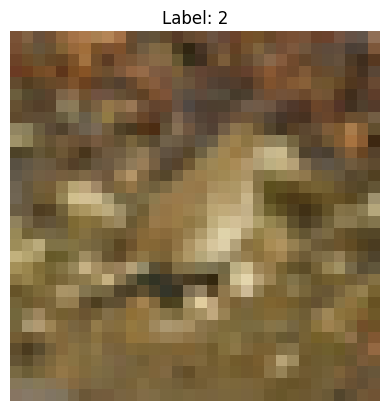

In [12]:
index = 1_000
show_img(x_train[index], y_train[index])

In [13]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_CNN_MODEL_PATH)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (None, 16, 16, 64)        9664      
                                                                 
 sequential_7 (Sequential)   (None, 8, 8, 128)         222208    
                                                                 
 sequential_8 (Sequential)   (None, 4, 4, 128)         295936    
                                                                 
 sequential_9 (Sequential)   (None, 2, 2, 256)         295936    
                                                                 
 global_average_pooling2d_1   (None, 256)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                        

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 11s 23ms/step - loss: 1.4033 - accuracy: 0.4966 - val_loss: 2.6316 - val_accuracy: 0.2719
Epoch 2/100
313/313 [==============================] - 7s 21ms/step - loss: 0.9531 - accuracy: 0.6611 - val_loss: 1.5426 - val_accuracy: 0.5000
Epoch 3/100
313/313 [==============================] - 7s 21ms/step - loss: 0.7570 - accuracy: 0.7338 - val_loss: 1.0097 - val_accuracy: 0.6537
Epoch 4/100
313/313 [==============================] - 7s 21ms/step - loss: 0.6215 - accuracy: 0.7837 - val_loss: 0.9815 - val_accuracy: 0.6718
Epoch 5/100
313/313 [==============================] - 7s 21ms/step - loss: 0.5252 - accuracy: 0.8175 - val_loss: 0.9472 - val_accuracy: 0.6873
Epoch 6/100
313/313 [==============================] - 7s 21ms/step - loss: 0.4368 - accuracy: 0.8478 - val_loss: 0.9513 - val_accuracy: 0.6909
Epoch 7/100
313/313 [==============================] - 7s 21ms/step - loss: 0.3714 - accuracy: 0.8706 - val_loss: 1.0242 - val_accuracy

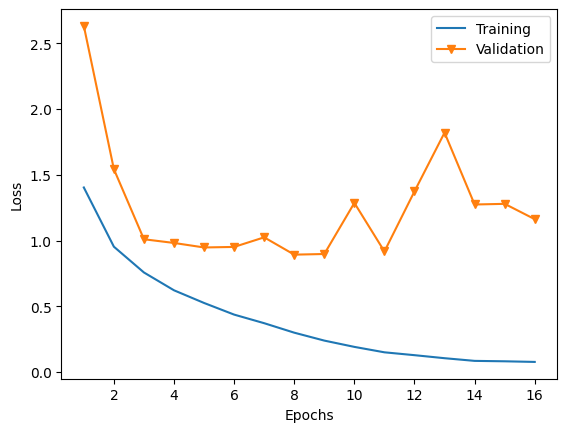

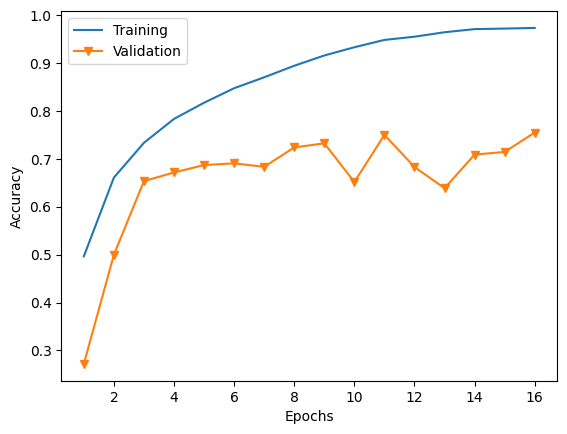

313/313 [==============================] - 1s 4ms/step - loss: 0.9191 - accuracy: 0.7528


[0.9191192388534546, 0.7527999877929688]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

## Hyperparameter-tuned DNN Model

In [3]:
feature_train, y_train, feature_val, y_val, feature_test, y_test = load_cifar10(return_features=True)

In [4]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_DNN_MODEL_PATH)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_353 (Ba  (None, 2048)             8192      
 tchNormalization)                                               
                                                                 
 sequential_336 (Sequential)  (None, 256)              525312    
                                                                 
 sequential_337 (Sequential)  (None, 128)              33280     
                                                                 
 dropout_488 (Dropout)       (None, 128)               0         
                                                                 
 dense (Dense)               (None, 10)                1290      
                                                                 
Total params: 568,074
Trainable params: 563,210
Non-trainable params: 4,864
______________________________________________

In [5]:
history = model.fit(
    feature_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 4s 9ms/step - loss: 0.5236 - accuracy: 0.8299 - val_loss: 0.3807 - val_accuracy: 0.8702
Epoch 2/100
313/313 [==============================] - 3s 8ms/step - loss: 0.3576 - accuracy: 0.8787 - val_loss: 0.3280 - val_accuracy: 0.8882
Epoch 3/100
313/313 [==============================] - 3s 9ms/step - loss: 0.3113 - accuracy: 0.8926 - val_loss: 0.3211 - val_accuracy: 0.8878
Epoch 4/100
313/313 [==============================] - 3s 8ms/step - loss: 0.2811 - accuracy: 0.9026 - val_loss: 0.3181 - val_accuracy: 0.8899
Epoch 5/100
313/313 [==============================] - 2s 8ms/step - loss: 0.2555 - accuracy: 0.9121 - val_loss: 0.3176 - val_accuracy: 0.8935
Epoch 6/100
313/313 [==============================] - 3s 8ms/step - loss: 0.2357 - accuracy: 0.9183 - val_loss: 0.3181 - val_accuracy: 0.8958
Epoch 7/100
313/313 [==============================] - 3s 8ms/step - loss: 0.2226 - accuracy: 0.9214 - val_loss: 0.3235 - val_accuracy: 0.8954

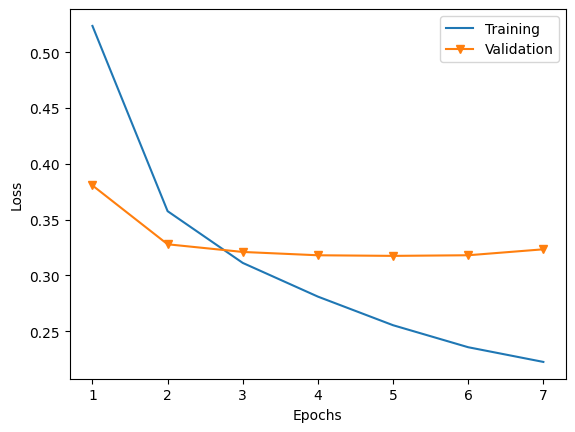

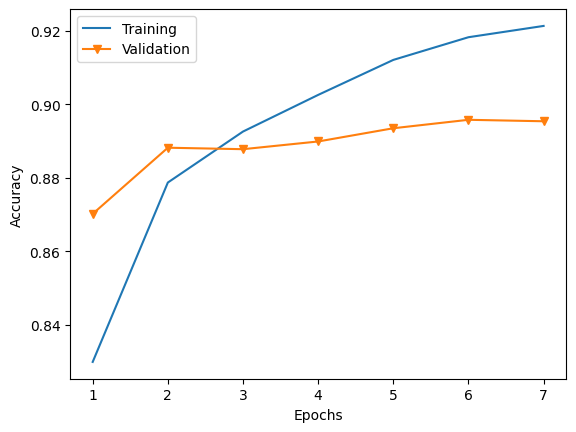

313/313 [==============================] - 1s 4ms/step - loss: 0.3295 - accuracy: 0.8887


[0.32947906851768494, 0.888700008392334]

In [6]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Transfer Learning with the pre-trained Xception Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(preprocess=False, verbose=0)

In [12]:
feature_train, feature_val, feature_test = extract_features(
    [x_train, x_val, x_test], 
    batch_size=BATCH_SIZE, 
    file_name="./data/cifar10_xception_gavgpooled_features_train_val_test"
)

79/79 [==============================] - 73s 940ms/step


In [ ]:
feature_train, feature_val, feature_test = load_samples(
    "./data/cifar10_xception_gavgpooled_features_train_val_test", 
    ".npy"
)

In [13]:
model = get_model(CLASS_NUM, model_type="DNN", dropout_rate=0.5)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 2048)              0         
                                                                 
 dense_1 (Dense)             (None, 10)                20490     
                                                                 
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
_________________________________________________________________


In [14]:
history = model.fit(
    feature_train, y_train,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
1250/1250 [==============================] - 5s 3ms/step - loss: 0.5361 - accuracy: 0.8285 - val_loss: 0.3863 - val_accuracy: 0.8721
Epoch 2/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3932 - accuracy: 0.8654 - val_loss: 0.3503 - val_accuracy: 0.8823
Epoch 3/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3732 - accuracy: 0.8723 - val_loss: 0.3413 - val_accuracy: 0.8801
Epoch 4/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3636 - accuracy: 0.8747 - val_loss: 0.3416 - val_accuracy: 0.8793
Epoch 5/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3554 - accuracy: 0.8781 - val_loss: 0.3305 - val_accuracy: 0.8827
Epoch 6/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3528 - accuracy: 0.8779 - val_loss: 0.3327 - val_accuracy: 0.8833
Epoch 7/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3501 - accuracy: 0.8789 - val_loss: 0.3277 - val_ac

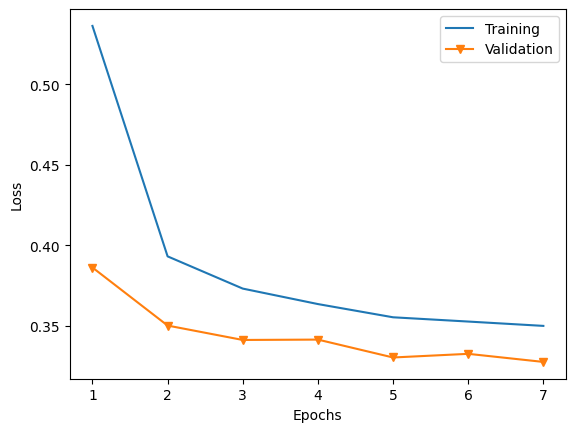

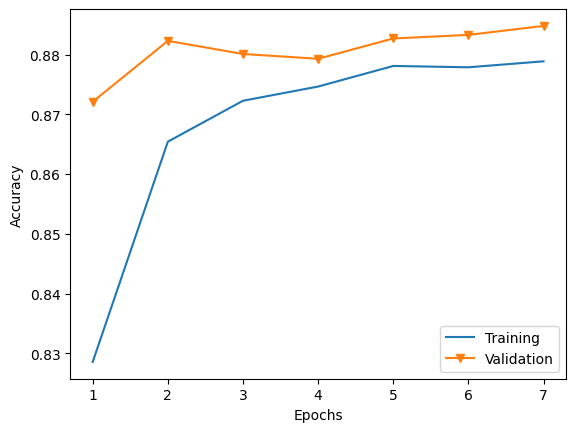

313/313 [==============================] - 1s 3ms/step - loss: 0.3587 - accuracy: 0.8788


[0.35869887471199036, 0.8787999749183655]

In [15]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Fine-tuning the pre-trained Xception Model

In [9]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(preprocess=False, verbose=0)

In [12]:
model = get_model(CLASS_NUM, model_type="pretrained", num_last_not_frozen=12, dropout_rate=0.50)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resize (Lambda)             (None, 299, 299, 3)       0         
                                                                 
 xception_preprocess (Lambda  (None, 299, 299, 3)      0         
 )                                                               
                                                                 
 xception (Functional)       (None, 10, 10, 2048)      20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 10)                2

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 804s 3s/step - loss: 0.3157 - accuracy: 0.8951 - val_loss: 0.2794 - val_accuracy: 0.9133
Epoch 2/100
313/313 [==============================] - 833s 3s/step - loss: 0.1676 - accuracy: 0.9423 - val_loss: 0.2581 - val_accuracy: 0.9157
Epoch 3/100
313/313 [==============================] - 666s 2s/step - loss: 0.1059 - accuracy: 0.9624 - val_loss: 0.2893 - val_accuracy: 0.9163
Epoch 4/100
313/313 [==============================] - 495s 2s/step - loss: 0.0650 - accuracy: 0.9777 - val_loss: 0.3214 - val_accuracy: 0.9159
Epoch 5/100
313/313 [==============================] - 828s 3s/step - loss: 0.0417 - accuracy: 0.9857 - val_loss: 0.2883 - val_accuracy: 0.9222
Epoch 6/100
313/313 [==============================] - 871s 3s/step - loss: 0.0360 - accuracy: 0.9877 - val_loss: 0.3195 - val_accuracy: 0.9259
Epoch 7/100
313/313 [==============================] - 681s 2s/step - loss: 0.0318 - accuracy: 0.9886 - val_loss: 0.3426 - val_accuracy:

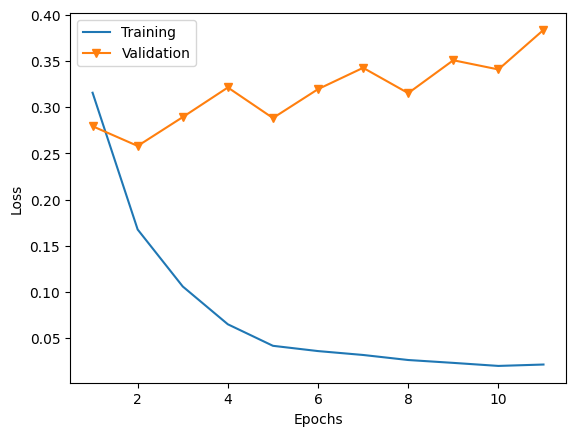

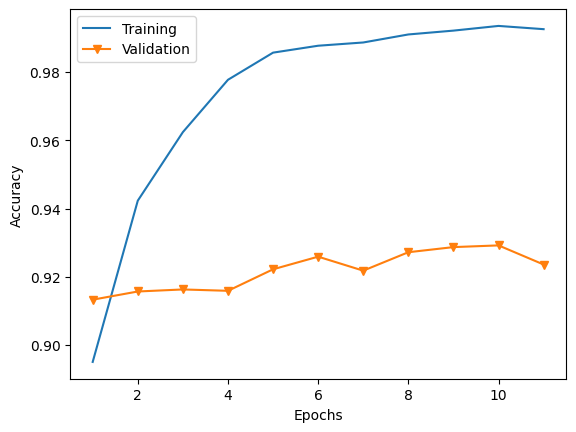

313/313 [==============================] - 159s 488ms/step - loss: 0.3389 - accuracy: 0.9225


[0.338937371969223, 0.9225000143051147]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

# Continual Learning

## Continually adding classes to different models

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 13.
Epoch 18: early stopping


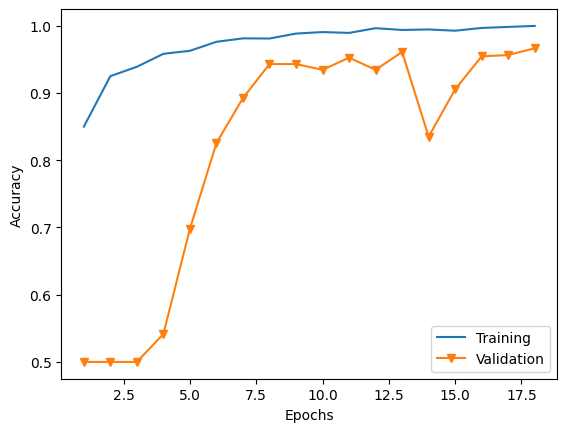

63/63 [==============================] - 0s 4ms/step
              precision    recall  f1-score   support

           0     0.9775    0.9540    0.9656      1000
           1     0.9551    0.9780    0.9664      1000

    accuracy                         0.9660      2000
   macro avg     0.9663    0.9660    0.9660      2000
weighted avg     0.9663    0.9660    0.9660      2000



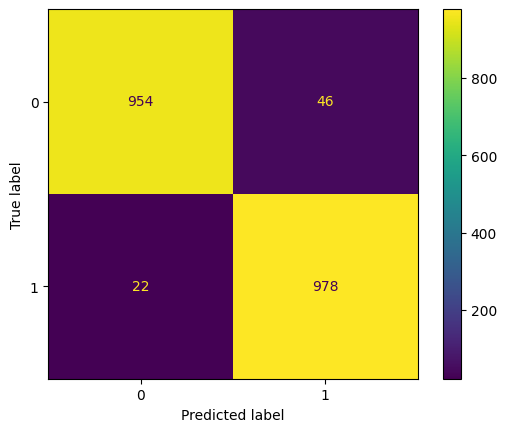

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 7.
Epoch 12: early stopping


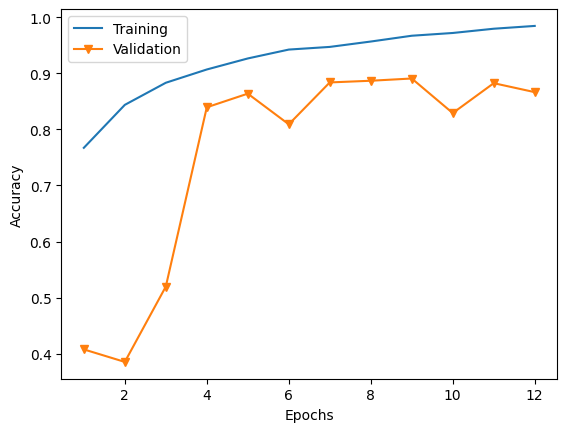

94/94 [==============================] - 0s 4ms/step
              precision    recall  f1-score   support

           0     0.8438    0.8970    0.8696      1000
           1     0.8877    0.9800    0.9316      1000
           2     0.9424    0.7850    0.8565      1000

    accuracy                         0.8873      3000
   macro avg     0.8913    0.8873    0.8859      3000
weighted avg     0.8913    0.8873    0.8859      3000



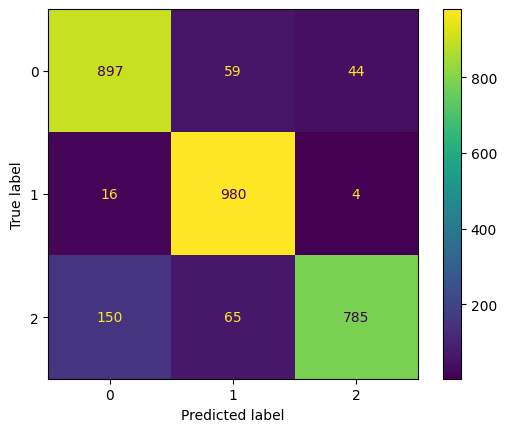

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


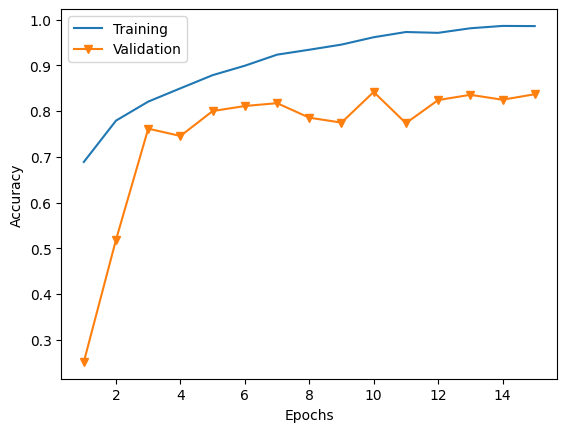

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.8745    0.8220    0.8474      1000
           1     0.9593    0.9200    0.9393      1000
           2     0.7025    0.9020    0.7898      1000
           3     0.8788    0.7180    0.7903      1000

    accuracy                         0.8405      4000
   macro avg     0.8538    0.8405    0.8417      4000
weighted avg     0.8538    0.8405    0.8417      4000



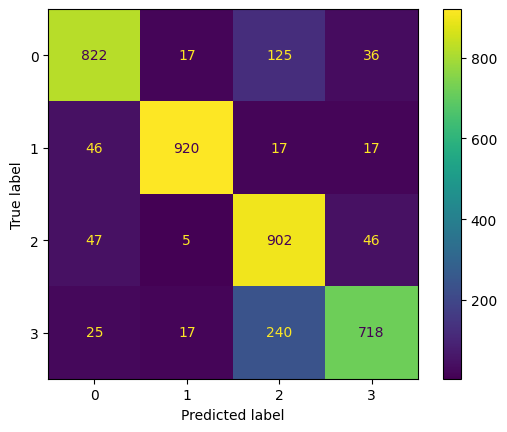

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 13.
Epoch 18: early stopping


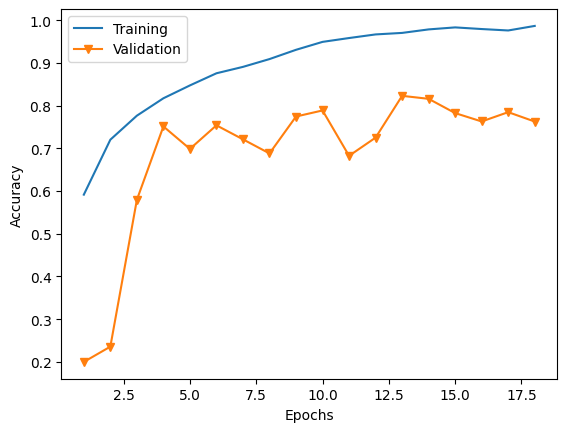

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8570    0.8870    0.8717      1000
           1     0.9799    0.8770    0.9256      1000
           2     0.7395    0.7380    0.7387      1000
           3     0.6822    0.8330    0.7501      1000
           4     0.8602    0.7320    0.7909      1000

    accuracy                         0.8134      5000
   macro avg     0.8238    0.8134    0.8154      5000
weighted avg     0.8238    0.8134    0.8154      5000



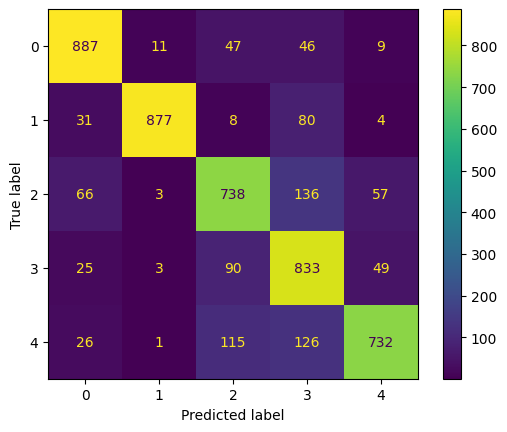

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 11.
Epoch 16: early stopping


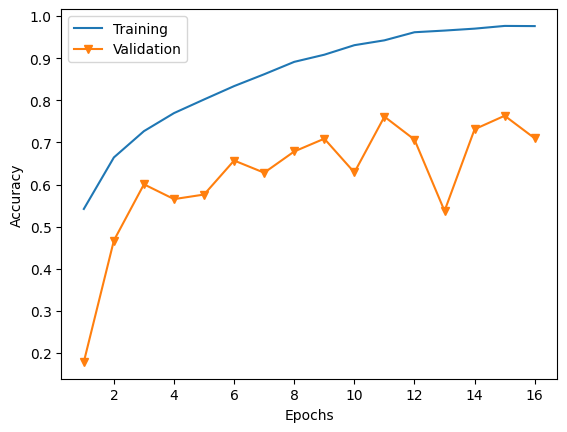

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8401    0.8880    0.8634      1000
           1     0.9582    0.9390    0.9485      1000
           2     0.7438    0.6940    0.7181      1000
           3     0.5098    0.8620    0.6407      1000
           4     0.8161    0.7590    0.7865      1000
           5     0.9144    0.3740    0.5309      1000

    accuracy                         0.7527      6000
   macro avg     0.7971    0.7527    0.7480      6000
weighted avg     0.7971    0.7527    0.7480      6000



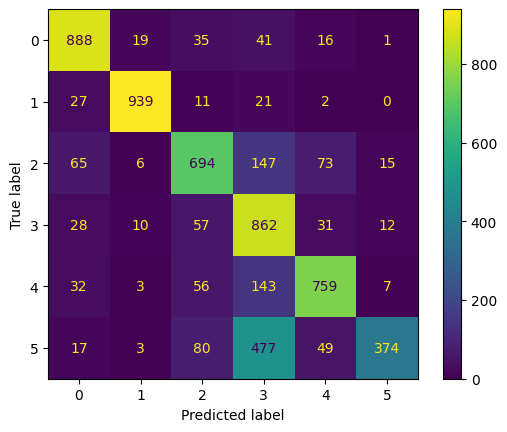

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 12.
Epoch 17: early stopping


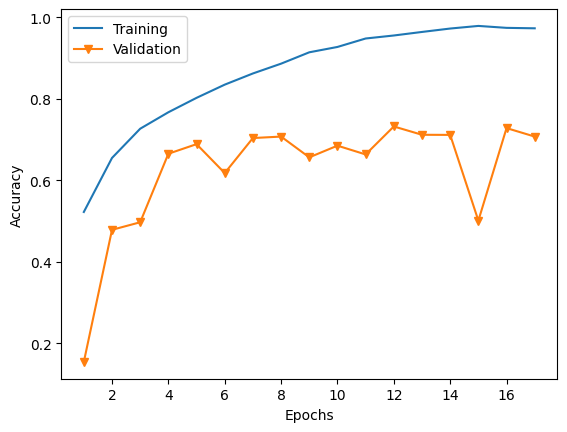

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.6712    0.9290    0.7794      1000
           1     0.9636    0.8470    0.9015      1000
           2     0.5864    0.8180    0.6831      1000
           3     0.5547    0.7400    0.6341      1000
           4     0.8177    0.7220    0.7669      1000
           5     0.9519    0.3560    0.5182      1000
           6     0.9387    0.7050    0.8053      1000

    accuracy                         0.7310      7000
   macro avg     0.7835    0.7310    0.7269      7000
weighted avg     0.7835    0.7310    0.7269      7000



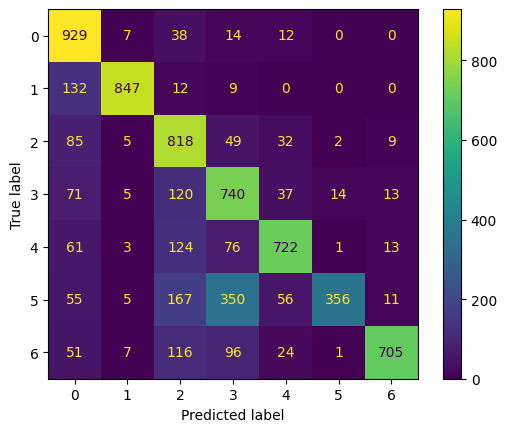

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


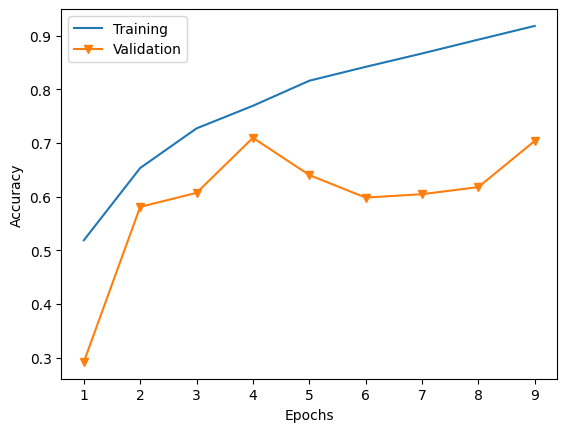

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.6667    0.8780    0.7579      1000
           1     0.8743    0.9530    0.9120      1000
           2     0.6042    0.6060    0.6051      1000
           3     0.7057    0.3980    0.5090      1000
           4     0.6401    0.7150    0.6755      1000
           5     0.7454    0.4860    0.5884      1000
           6     0.6954    0.8720    0.7737      1000
           7     0.7787    0.7810    0.7798      1000

    accuracy                         0.7111      8000
   macro avg     0.7138    0.7111    0.7002      8000
weighted avg     0.7138    0.7111    0.7002      8000



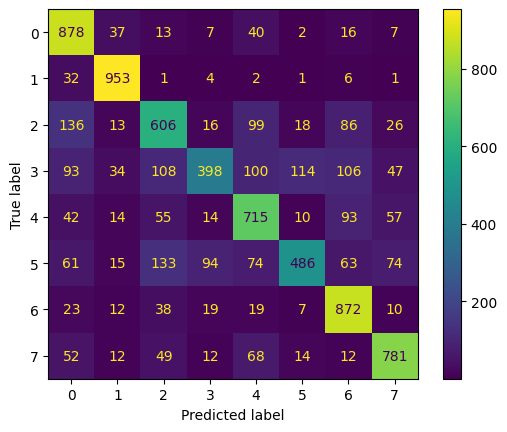

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


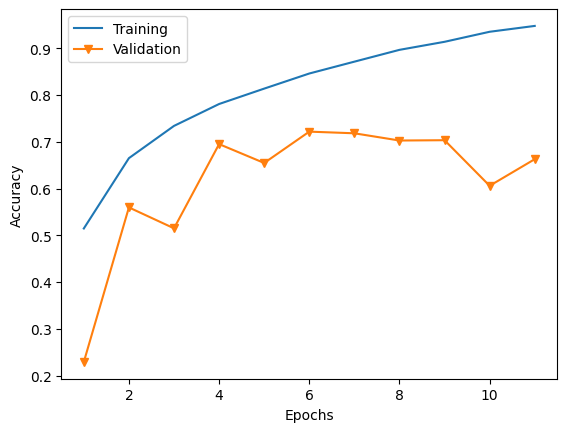

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.7058    0.8420    0.7679      1000
           1     0.9598    0.8590    0.9066      1000
           2     0.9568    0.2880    0.4427      1000
           3     0.5118    0.7130    0.5959      1000
           4     0.6584    0.7210    0.6883      1000
           5     0.5664    0.7170    0.6328      1000
           6     0.7034    0.8800    0.7819      1000
           7     0.8208    0.7330    0.7744      1000
           8     0.9593    0.6840    0.7986      1000

    accuracy                         0.7152      9000
   macro avg     0.7603    0.7152    0.7099      9000
weighted avg     0.7603    0.7152    0.7099      9000



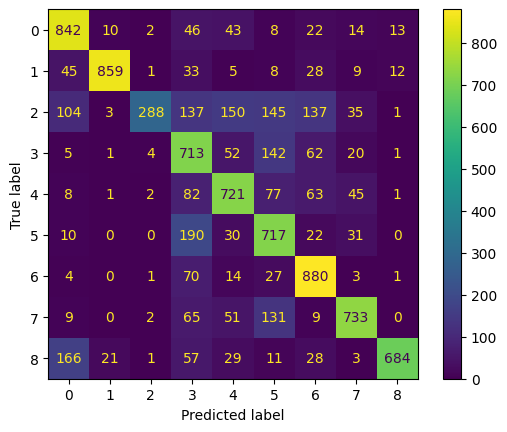

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


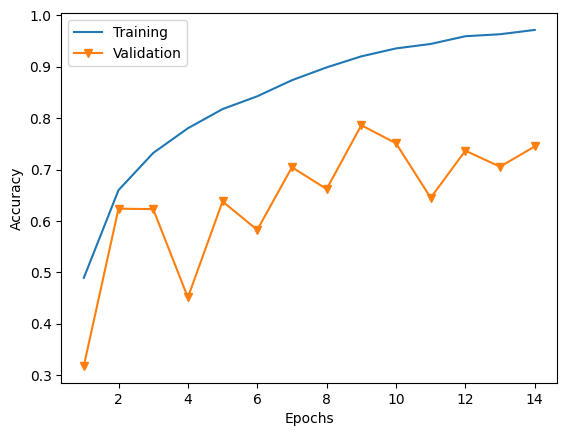

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.7942    0.8530    0.8226      1000
           1     0.9115    0.8860    0.8986      1000
           2     0.6934    0.7080    0.7006      1000
           3     0.6418    0.5840    0.6115      1000
           4     0.7916    0.7330    0.7612      1000
           5     0.6762    0.7120    0.6936      1000
           6     0.6837    0.9100    0.7808      1000
           7     0.8722    0.7780    0.8224      1000
           8     0.9283    0.8160    0.8685      1000
           9     0.8928    0.8410    0.8661      1000

    accuracy                         0.7821     10000
   macro avg     0.7886    0.7821    0.7826     10000
weighted avg     0.7886    0.7821    0.7826     10000



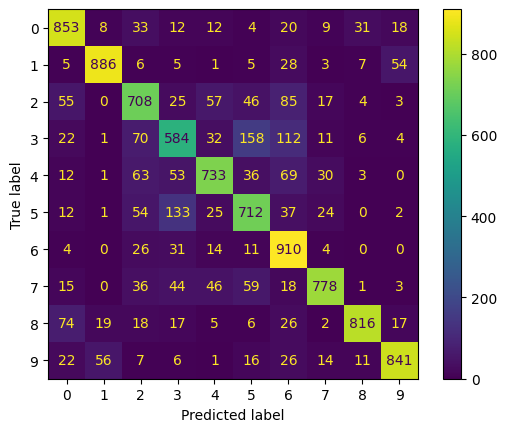

---------------------------------------------------------------------------



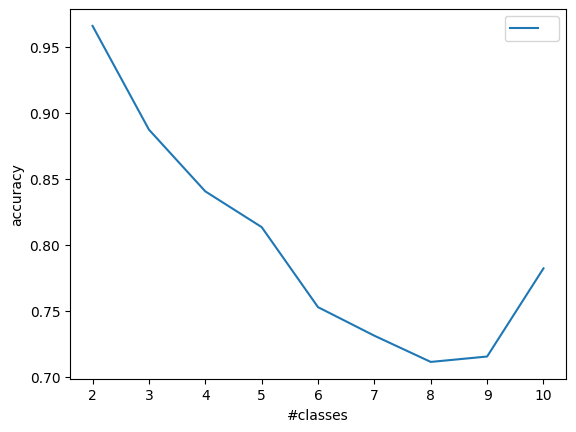

In [3]:
acc_list1 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=False, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


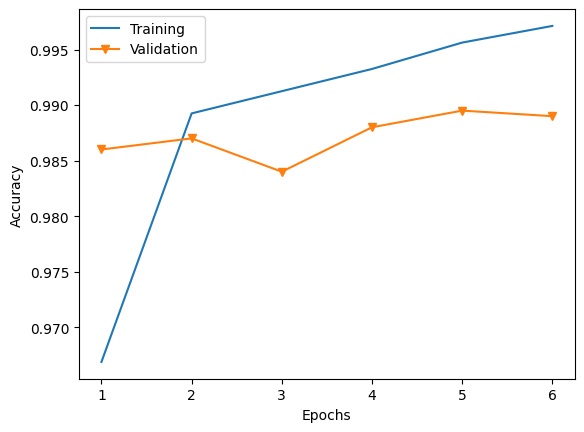

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9929    0.9760    0.9844      1000
           1     0.9764    0.9930    0.9846      1000

    accuracy                         0.9845      2000
   macro avg     0.9846    0.9845    0.9845      2000
weighted avg     0.9846    0.9845    0.9845      2000



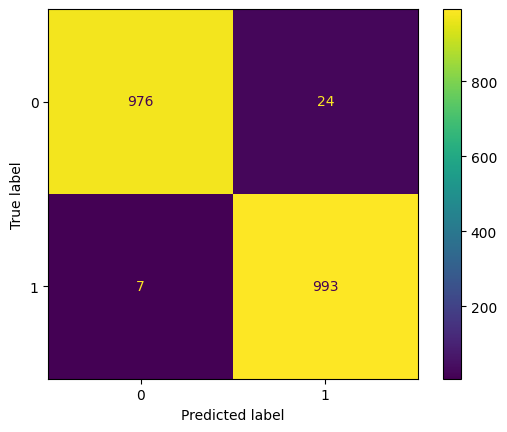

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


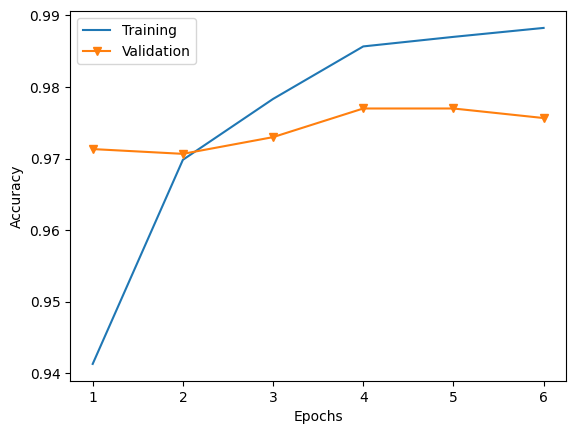

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9361    0.9810    0.9580      1000
           1     0.9929    0.9830    0.9879      1000
           2     0.9854    0.9480    0.9664      1000

    accuracy                         0.9707      3000
   macro avg     0.9715    0.9707    0.9708      3000
weighted avg     0.9715    0.9707    0.9708      3000



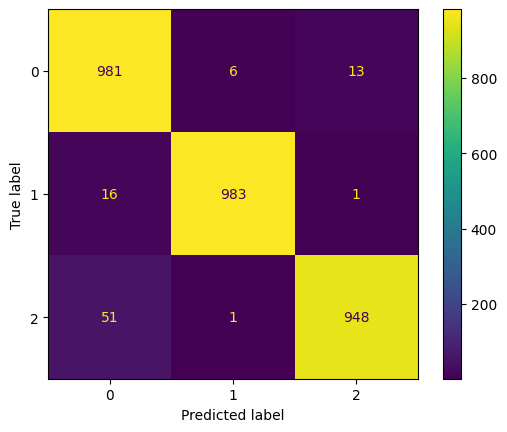

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


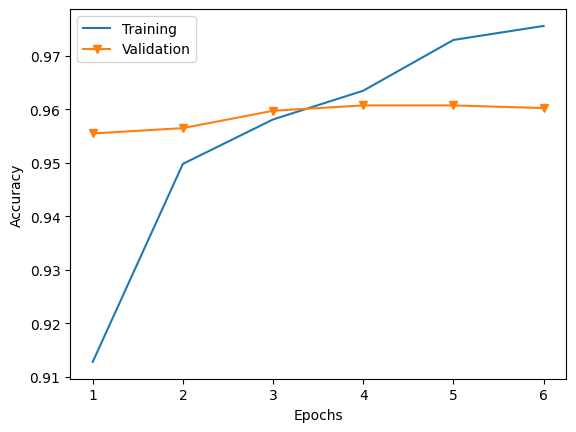

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9457    0.9400    0.9428      1000
           1     0.9888    0.9720    0.9803      1000
           2     0.9168    0.9150    0.9159      1000
           3     0.9122    0.9350    0.9235      1000

    accuracy                         0.9405      4000
   macro avg     0.9409    0.9405    0.9406      4000
weighted avg     0.9409    0.9405    0.9406      4000



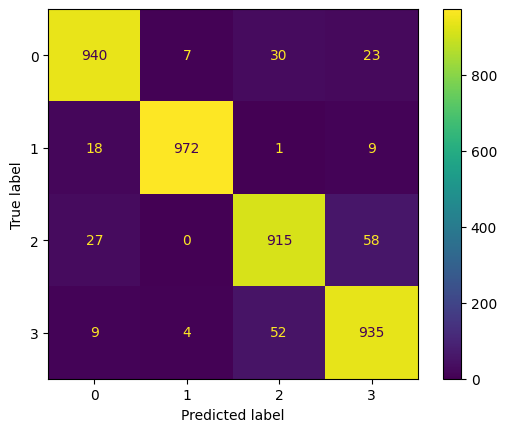

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


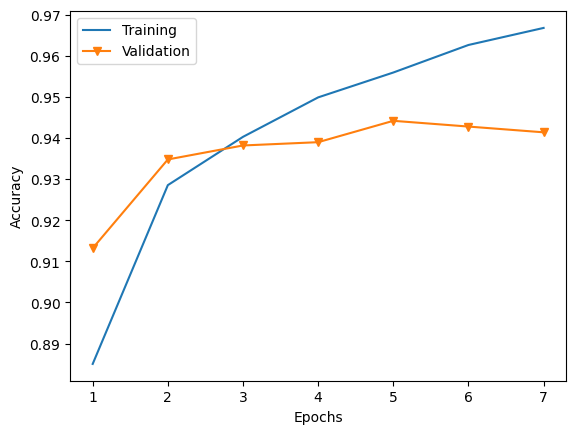

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9620    0.9370    0.9493      1000
           1     0.9850    0.9820    0.9835      1000
           2     0.9200    0.8850    0.9021      1000
           3     0.9034    0.9170    0.9102      1000
           4     0.9011    0.9480    0.9240      1000

    accuracy                         0.9338      5000
   macro avg     0.9343    0.9338    0.9338      5000
weighted avg     0.9343    0.9338    0.9338      5000



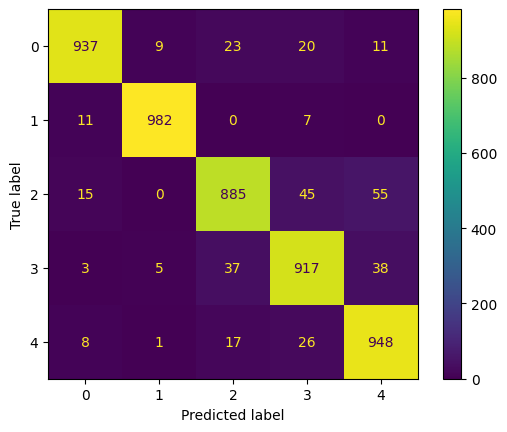

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


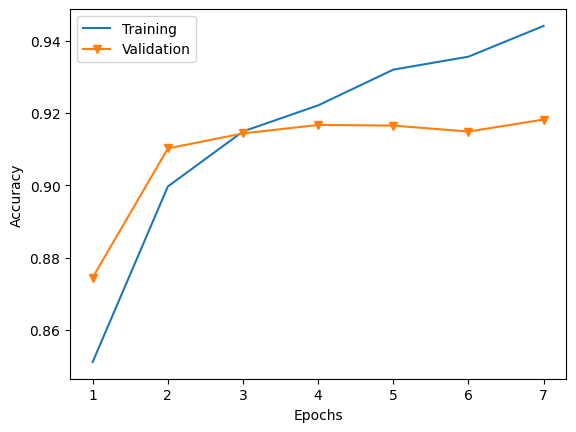

188/188 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9566    0.9470    0.9518      1000
           1     0.9839    0.9800    0.9820      1000
           2     0.8932    0.8780    0.8855      1000
           3     0.7764    0.8370    0.8056      1000
           4     0.9117    0.9090    0.9104      1000
           5     0.8734    0.8350    0.8538      1000

    accuracy                         0.8977      6000
   macro avg     0.8992    0.8977    0.8982      6000
weighted avg     0.8992    0.8977    0.8982      6000



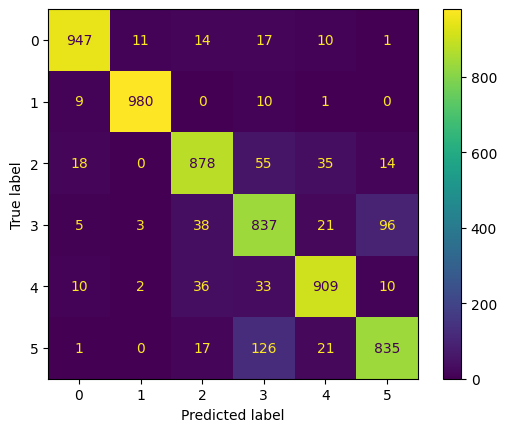

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


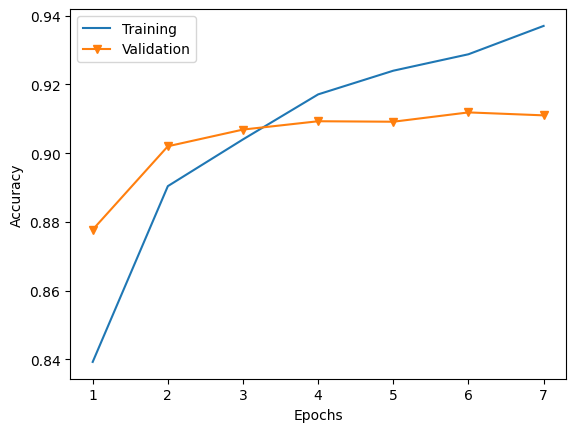

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9517    0.9460    0.9488      1000
           1     0.9869    0.9770    0.9819      1000
           2     0.9082    0.8510    0.8787      1000
           3     0.7607    0.8390    0.7979      1000
           4     0.8669    0.9250    0.8950      1000
           5     0.9078    0.8170    0.8600      1000
           6     0.9019    0.9100    0.9059      1000

    accuracy                         0.8950      7000
   macro avg     0.8977    0.8950    0.8955      7000
weighted avg     0.8977    0.8950    0.8955      7000



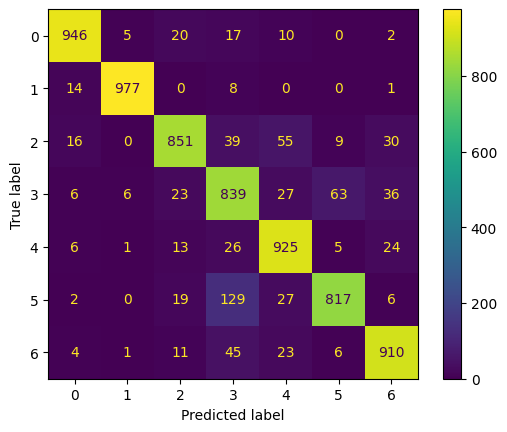

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


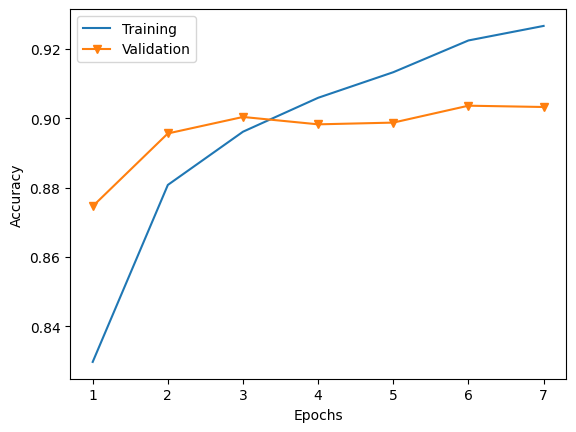

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9449    0.9440    0.9445      1000
           1     0.9801    0.9840    0.9820      1000
           2     0.9067    0.8260    0.8645      1000
           3     0.7242    0.8690    0.7900      1000
           4     0.8684    0.8780    0.8732      1000
           5     0.8997    0.8160    0.8558      1000
           6     0.9102    0.8920    0.9010      1000
           7     0.9211    0.9100    0.9155      1000

    accuracy                         0.8899      8000
   macro avg     0.8944    0.8899    0.8908      8000
weighted avg     0.8944    0.8899    0.8908      8000



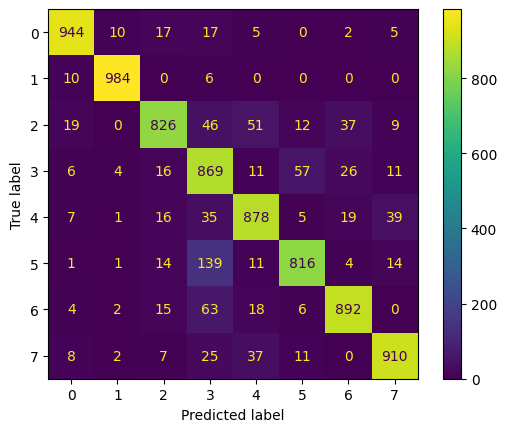

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


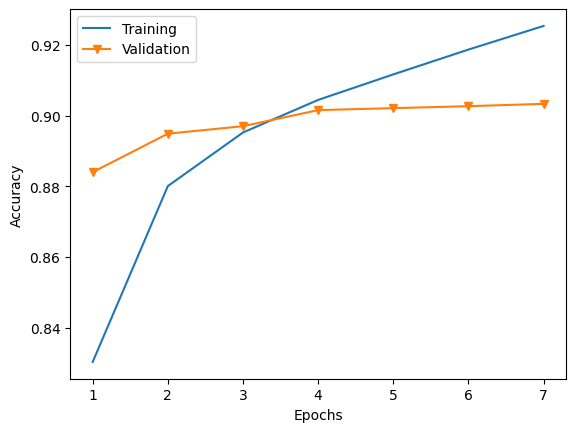

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9169    0.9050    0.9109      1000
           1     0.9808    0.9720    0.9764      1000
           2     0.8746    0.8580    0.8662      1000
           3     0.7611    0.8250    0.7917      1000
           4     0.8432    0.8820    0.8622      1000
           5     0.9045    0.7960    0.8468      1000
           6     0.9045    0.9090    0.9067      1000
           7     0.9018    0.9180    0.9098      1000
           8     0.9395    0.9470    0.9432      1000

    accuracy                         0.8902      9000
   macro avg     0.8919    0.8902    0.8904      9000
weighted avg     0.8919    0.8902    0.8904      9000



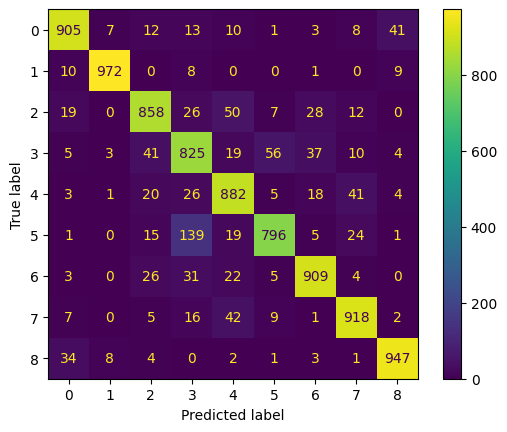

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


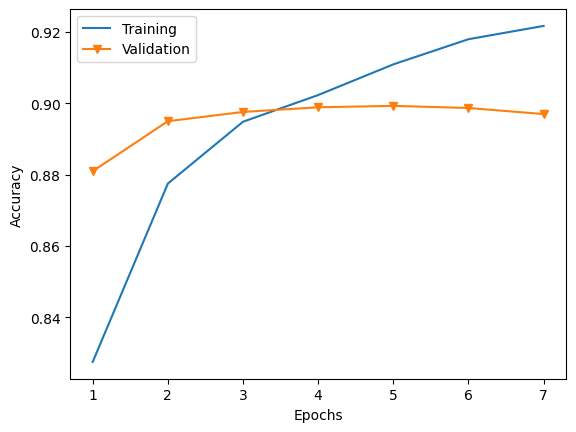

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8830    0.9060    0.8944      1000
           1     0.9429    0.9240    0.9333      1000
           2     0.9171    0.8300    0.8714      1000
           3     0.7670    0.8230    0.7940      1000
           4     0.8699    0.8690    0.8694      1000
           5     0.8771    0.8280    0.8519      1000
           6     0.8831    0.9220    0.9022      1000
           7     0.8922    0.9270    0.9093      1000
           8     0.9290    0.9290    0.9290      1000
           9     0.9222    0.9130    0.9176      1000

    accuracy                         0.8871     10000
   macro avg     0.8884    0.8871    0.8872     10000
weighted avg     0.8884    0.8871    0.8872     10000



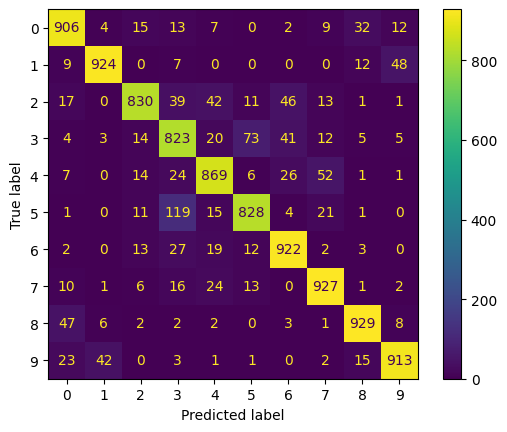

---------------------------------------------------------------------------



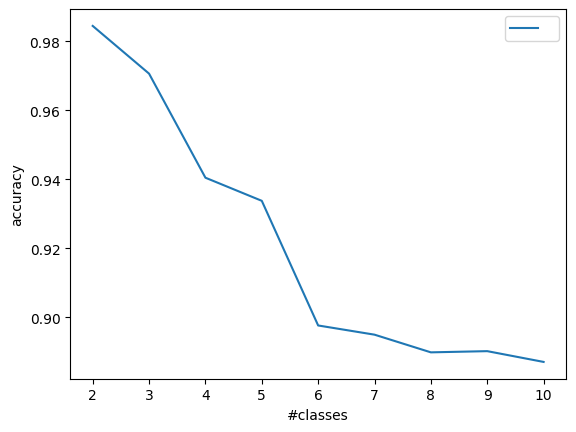

In [4]:
acc_list2 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=False, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

## Continually adding classes to the same model

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


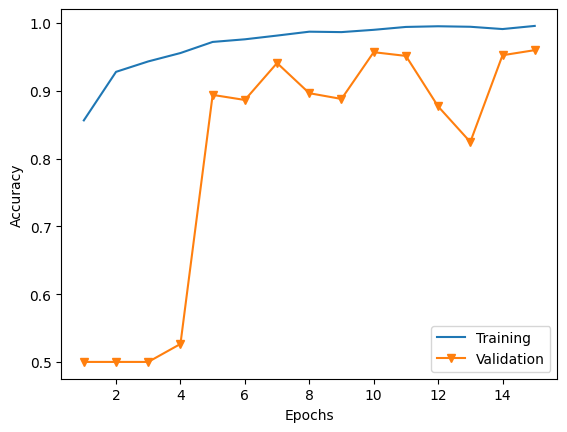

63/63 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9371    0.9690    0.9528      1000
           1     0.9679    0.9350    0.9512      1000

    accuracy                         0.9520      2000
   macro avg     0.9525    0.9520    0.9520      2000
weighted avg     0.9525    0.9520    0.9520      2000



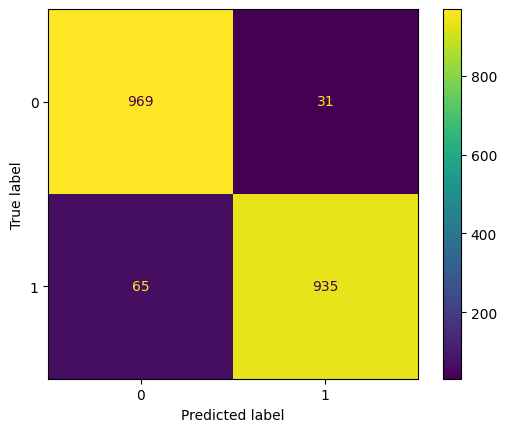

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


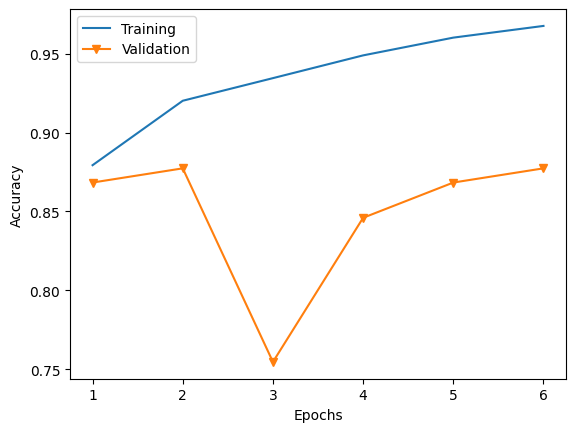

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.8128    0.8860    0.8478      1000
           1     0.9275    0.9460    0.9366      1000
           2     0.9000    0.8010    0.8476      1000

    accuracy                         0.8777      3000
   macro avg     0.8801    0.8777    0.8774      3000
weighted avg     0.8801    0.8777    0.8774      3000



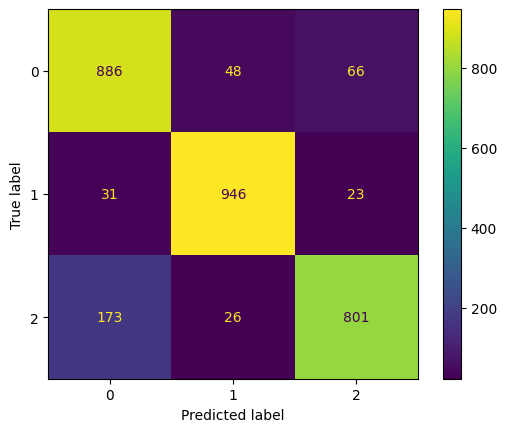

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 8.
Epoch 13: early stopping


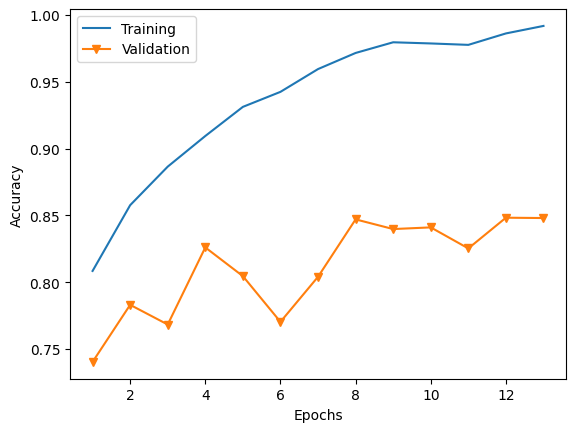

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.8015    0.9370    0.8640      1000
           1     0.9588    0.9300    0.9442      1000
           2     0.8956    0.6520    0.7546      1000
           3     0.7688    0.8710    0.8167      1000

    accuracy                         0.8475      4000
   macro avg     0.8562    0.8475    0.8449      4000
weighted avg     0.8562    0.8475    0.8449      4000



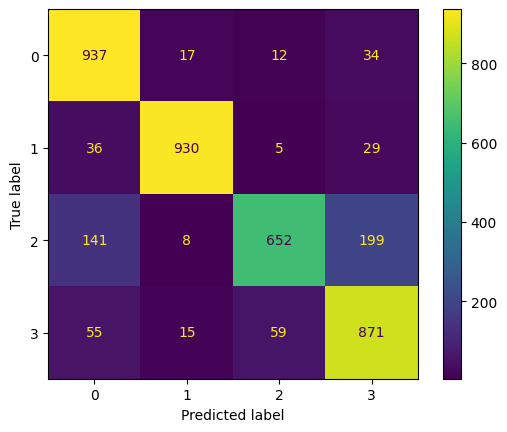

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 7.
Epoch 12: early stopping


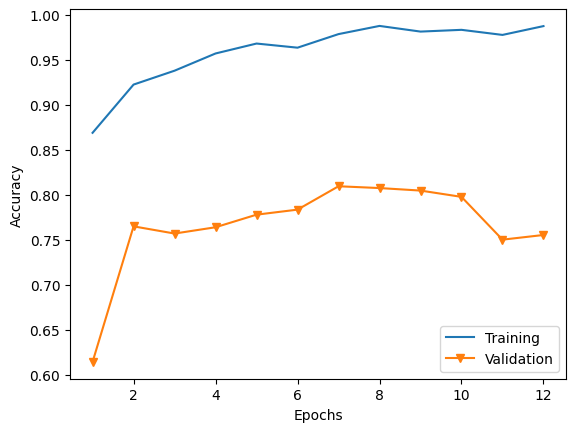

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8196    0.9040    0.8597      1000
           1     0.9666    0.9270    0.9464      1000
           2     0.6776    0.8050    0.7358      1000
           3     0.8598    0.5950    0.7033      1000
           4     0.7306    0.7730    0.7512      1000

    accuracy                         0.8008      5000
   macro avg     0.8109    0.8008    0.7993      5000
weighted avg     0.8109    0.8008    0.7993      5000



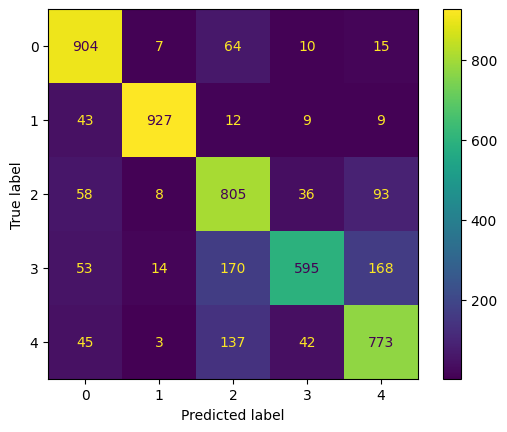

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


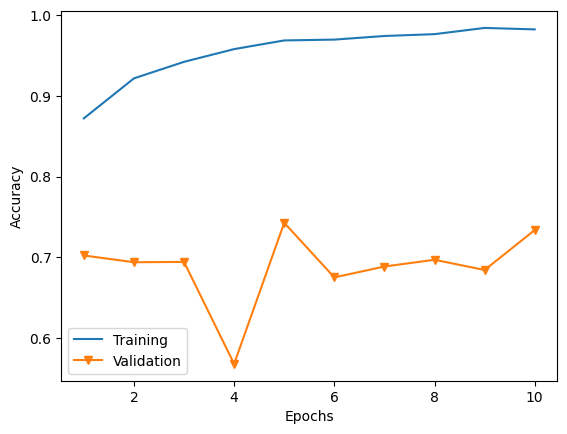

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.9193    0.7860    0.8474      1000
           1     0.9849    0.8480    0.9113      1000
           2     0.7137    0.6680    0.6901      1000
           3     0.6103    0.6030    0.6066      1000
           4     0.6651    0.8300    0.7384      1000
           5     0.6070    0.6750    0.6392      1000

    accuracy                         0.7350      6000
   macro avg     0.7500    0.7350    0.7389      6000
weighted avg     0.7500    0.7350    0.7389      6000



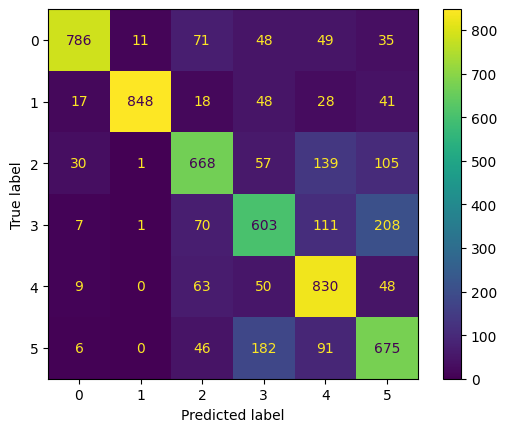

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


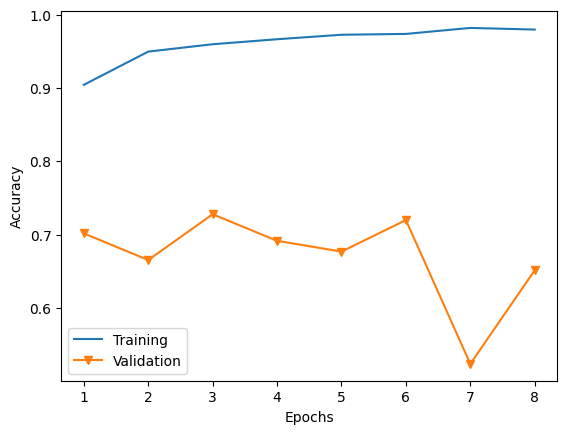

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8901    0.8100    0.8482      1000
           1     0.9912    0.7930    0.8811      1000
           2     0.7975    0.5630    0.6600      1000
           3     0.6319    0.5150    0.5675      1000
           4     0.6974    0.7650    0.7296      1000
           5     0.6682    0.7130    0.6899      1000
           6     0.5607    0.9000    0.6910      1000

    accuracy                         0.7227      7000
   macro avg     0.7481    0.7227    0.7239      7000
weighted avg     0.7481    0.7227    0.7239      7000



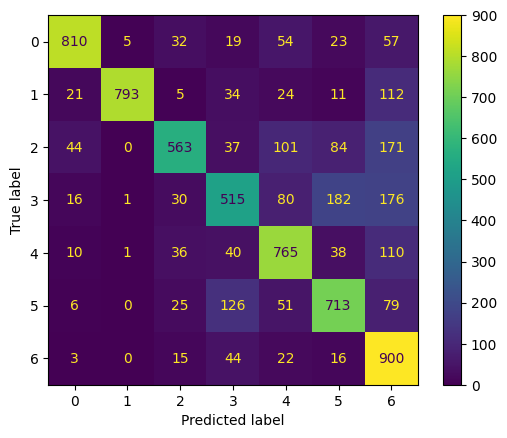

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


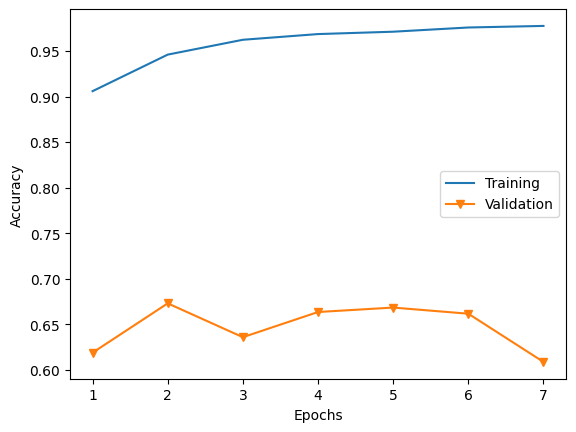

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.7946    0.8470    0.8199      1000
           1     0.8281    0.9680    0.8926      1000
           2     0.5358    0.7480    0.6244      1000
           3     0.7347    0.3130    0.4390      1000
           4     0.7792    0.4200    0.5458      1000
           5     0.6347    0.5750    0.6034      1000
           6     0.4973    0.9090    0.6429      1000
           7     0.8045    0.5390    0.6455      1000

    accuracy                         0.6649      8000
   macro avg     0.7011    0.6649    0.6517      8000
weighted avg     0.7011    0.6649    0.6517      8000



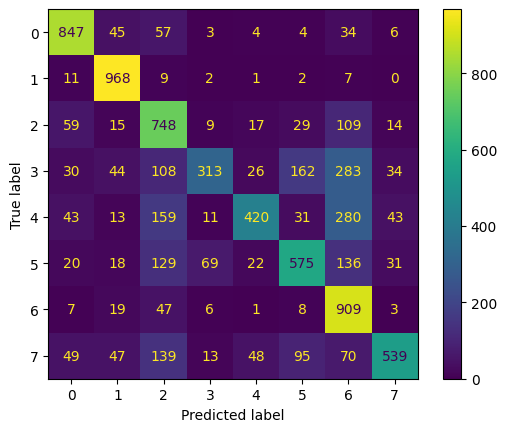

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


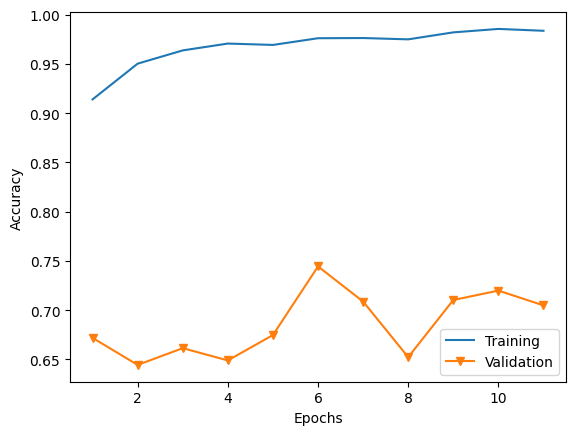

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8196    0.8040    0.8117      1000
           1     0.9067    0.9430    0.9245      1000
           2     0.7750    0.5890    0.6693      1000
           3     0.5403    0.6300    0.5817      1000
           4     0.7109    0.7180    0.7144      1000
           5     0.7088    0.6230    0.6631      1000
           6     0.7104    0.8610    0.7785      1000
           7     0.8017    0.7400    0.7696      1000
           8     0.8280    0.8520    0.8398      1000

    accuracy                         0.7511      9000
   macro avg     0.7557    0.7511    0.7503      9000
weighted avg     0.7557    0.7511    0.7503      9000



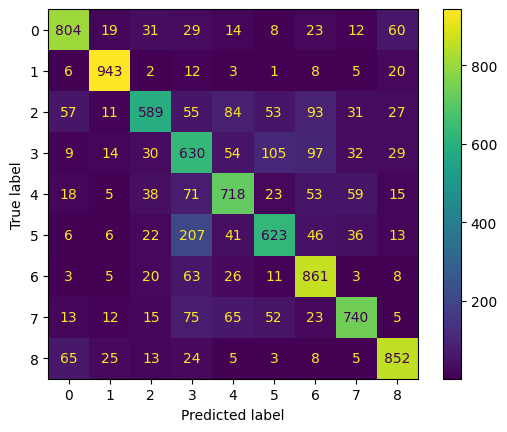

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


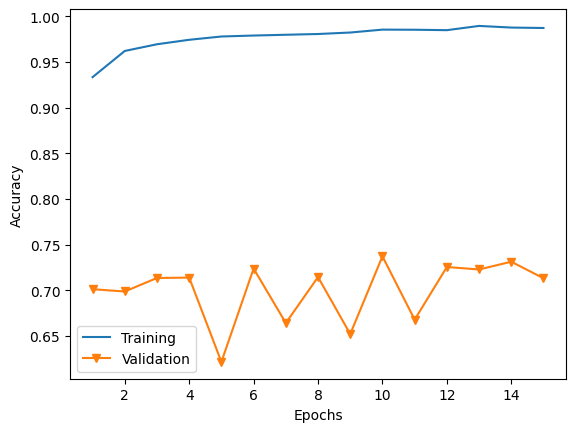

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.9135    0.5600    0.6944      1000
           1     0.8383    0.9070    0.8713      1000
           2     0.6939    0.6370    0.6642      1000
           3     0.7398    0.4150    0.5317      1000
           4     0.7345    0.6890    0.7110      1000
           5     0.6853    0.6990    0.6921      1000
           6     0.5717    0.9410    0.7113      1000
           7     0.8088    0.7700    0.7889      1000
           8     0.6994    0.9260    0.7969      1000
           9     0.8171    0.7730    0.7945      1000

    accuracy                         0.7317     10000
   macro avg     0.7502    0.7317    0.7256     10000
weighted avg     0.7502    0.7317    0.7256     10000



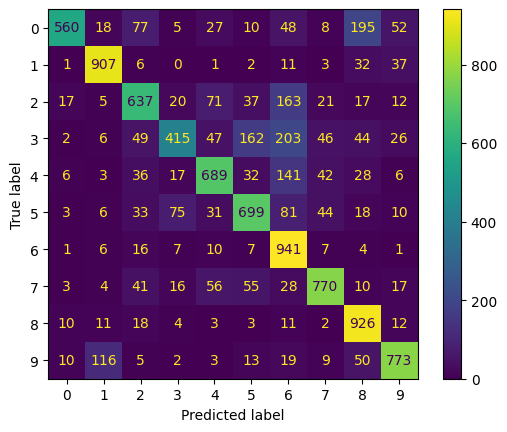

---------------------------------------------------------------------------



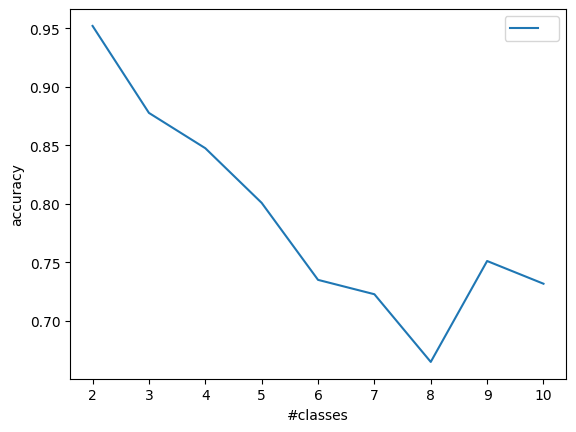

In [5]:
acc_list3 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=True, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


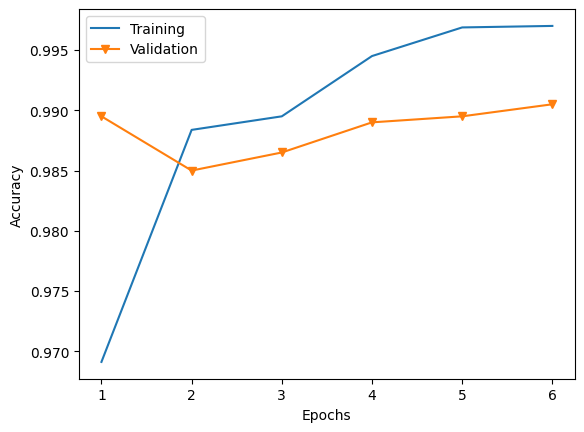

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9880    0.9850    0.9865      1000
           1     0.9850    0.9880    0.9865      1000

    accuracy                         0.9865      2000
   macro avg     0.9865    0.9865    0.9865      2000
weighted avg     0.9865    0.9865    0.9865      2000



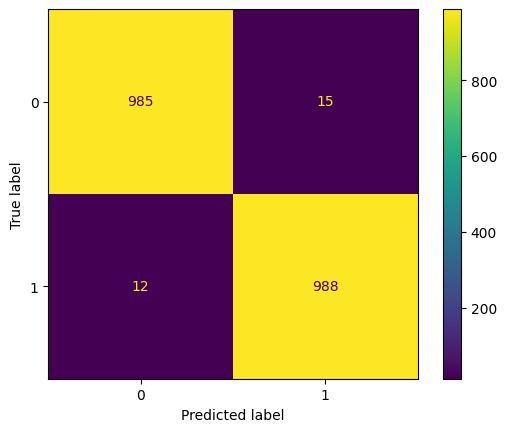

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


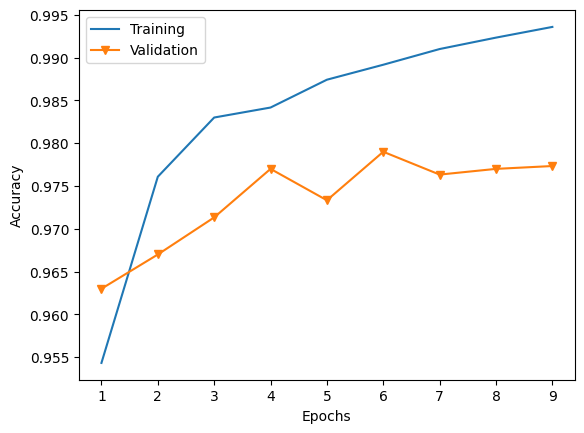

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9727    0.9610    0.9668      1000
           1     0.9812    0.9920    0.9866      1000
           2     0.9780    0.9790    0.9785      1000

    accuracy                         0.9773      3000
   macro avg     0.9773    0.9773    0.9773      3000
weighted avg     0.9773    0.9773    0.9773      3000



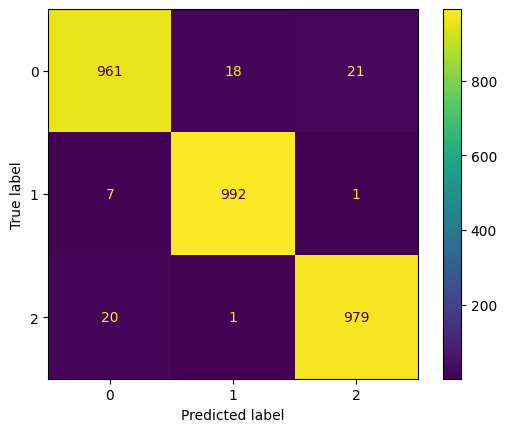

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


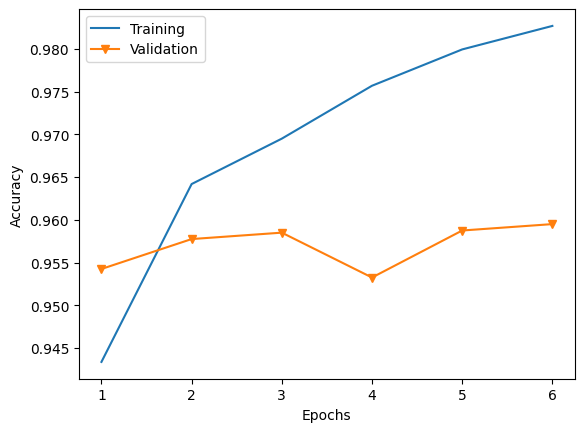

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9685    0.9530    0.9607      1000
           1     0.9919    0.9830    0.9874      1000
           2     0.9632    0.8910    0.9257      1000
           3     0.8818    0.9700    0.9238      1000

    accuracy                         0.9493      4000
   macro avg     0.9514    0.9492    0.9494      4000
weighted avg     0.9514    0.9493    0.9494      4000



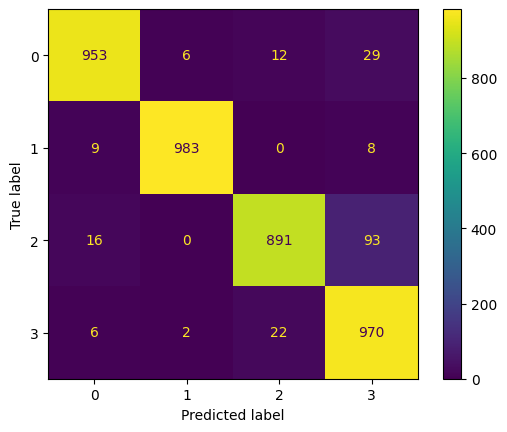

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


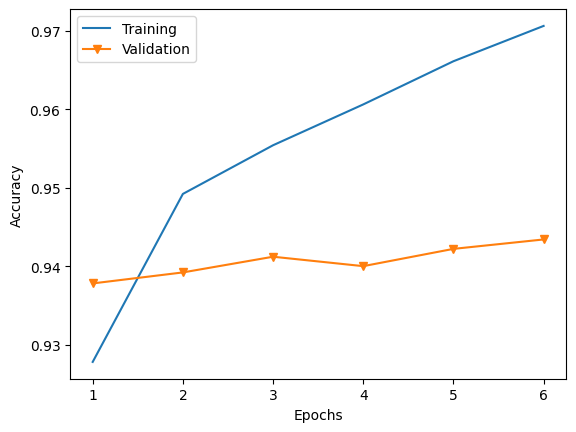

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9655    0.9510    0.9582      1000
           1     0.9879    0.9800    0.9839      1000
           2     0.9529    0.8500    0.8985      1000
           3     0.8912    0.9340    0.9121      1000
           4     0.8790    0.9520    0.9141      1000

    accuracy                         0.9334      5000
   macro avg     0.9353    0.9334    0.9334      5000
weighted avg     0.9353    0.9334    0.9334      5000



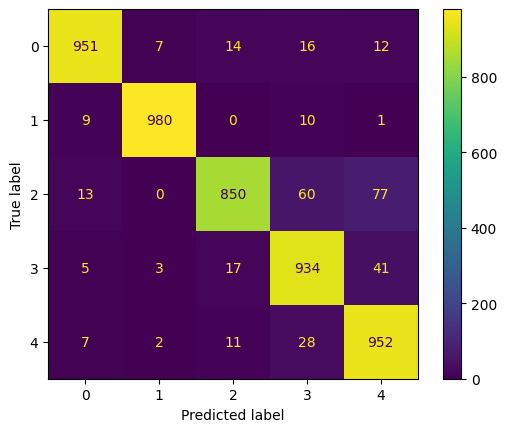

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


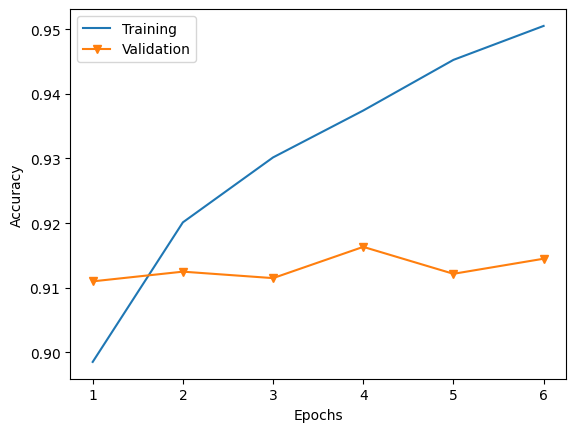

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9591    0.9610    0.9600      1000
           1     0.9919    0.9840    0.9880      1000
           2     0.9325    0.8700    0.9002      1000
           3     0.7966    0.8460    0.8206      1000
           4     0.8976    0.9380    0.9174      1000
           5     0.8727    0.8430    0.8576      1000

    accuracy                         0.9070      6000
   macro avg     0.9084    0.9070    0.9073      6000
weighted avg     0.9084    0.9070    0.9073      6000



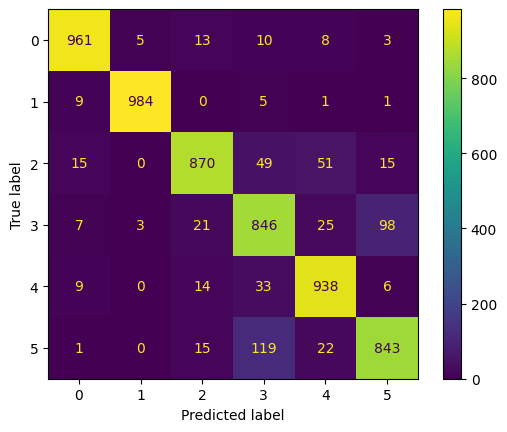

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


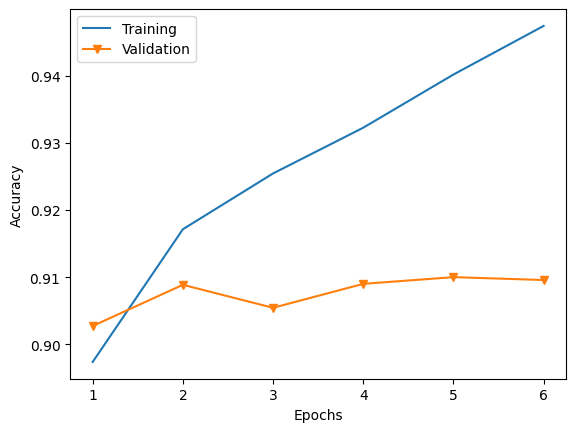

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9587    0.9520    0.9553      1000
           1     0.9889    0.9810    0.9849      1000
           2     0.9313    0.8400    0.8833      1000
           3     0.7866    0.8000    0.7933      1000
           4     0.8915    0.9120    0.9016      1000
           5     0.8555    0.8760    0.8656      1000
           6     0.8789    0.9220    0.9000      1000

    accuracy                         0.8976      7000
   macro avg     0.8988    0.8976    0.8977      7000
weighted avg     0.8988    0.8976    0.8977      7000



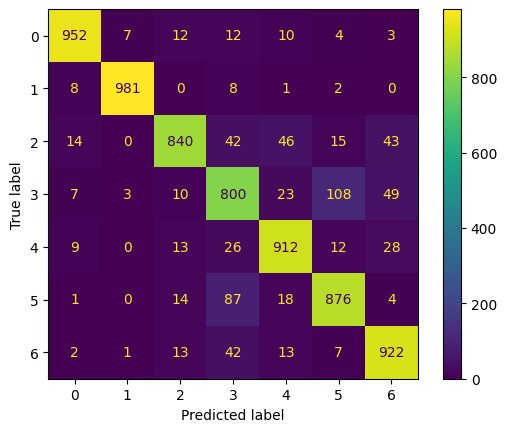

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


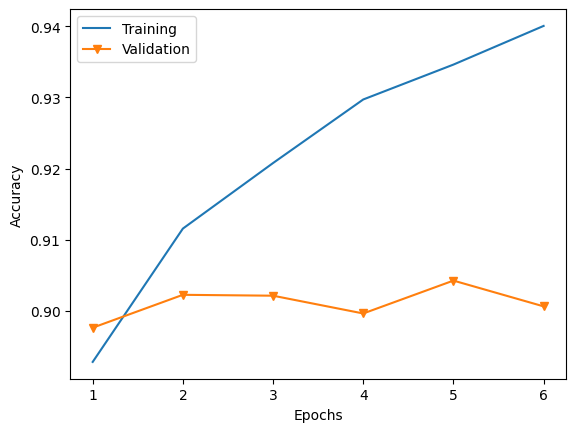

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9356    0.9590    0.9472      1000
           1     0.9909    0.9770    0.9839      1000
           2     0.9162    0.8420    0.8775      1000
           3     0.8151    0.7670    0.7903      1000
           4     0.8357    0.8850    0.8596      1000
           5     0.8442    0.8670    0.8555      1000
           6     0.8692    0.9300    0.8986      1000
           7     0.9168    0.8920    0.9042      1000

    accuracy                         0.8899      8000
   macro avg     0.8904    0.8899    0.8896      8000
weighted avg     0.8904    0.8899    0.8896      8000



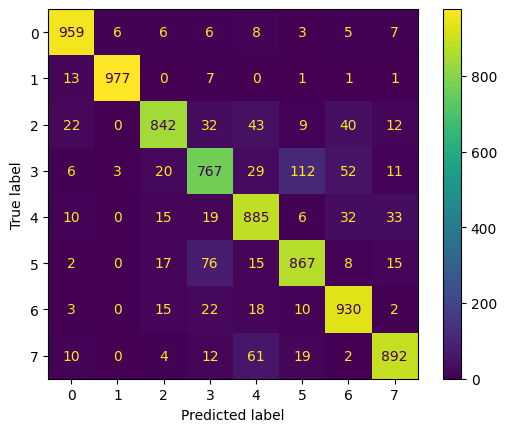

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


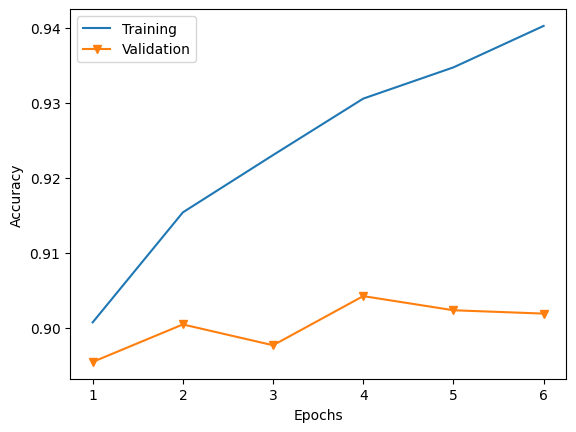

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9328    0.8740    0.9024      1000
           1     0.9819    0.9750    0.9784      1000
           2     0.9218    0.8370    0.8774      1000
           3     0.7665    0.8240    0.7942      1000
           4     0.8523    0.8890    0.8703      1000
           5     0.8819    0.8290    0.8546      1000
           6     0.8886    0.9250    0.9064      1000
           7     0.9114    0.9150    0.9132      1000
           8     0.9046    0.9580    0.9305      1000

    accuracy                         0.8918      9000
   macro avg     0.8935    0.8918    0.8919      9000
weighted avg     0.8935    0.8918    0.8919      9000



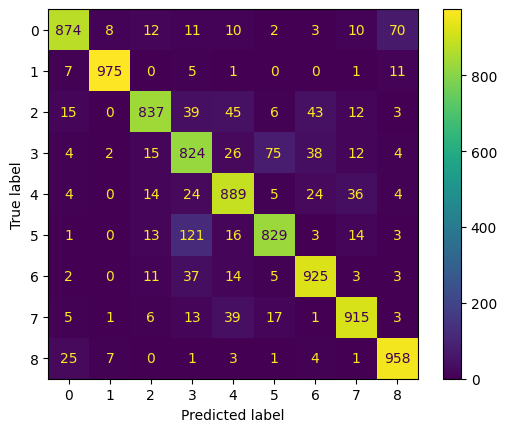

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


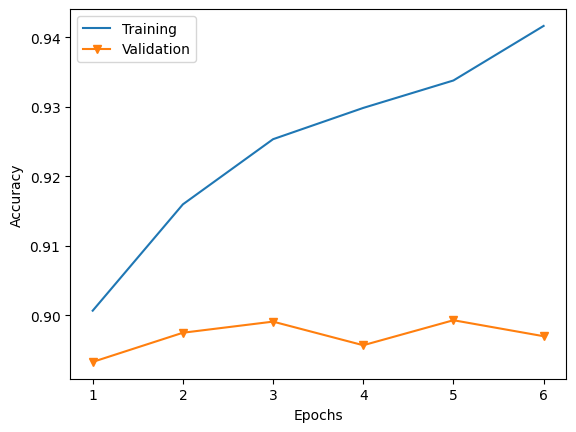

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9096    0.8950    0.9022      1000
           1     0.9654    0.8940    0.9283      1000
           2     0.8946    0.8660    0.8801      1000
           3     0.7964    0.7940    0.7952      1000
           4     0.8754    0.8850    0.8802      1000
           5     0.8696    0.8470    0.8582      1000
           6     0.9038    0.9210    0.9123      1000
           7     0.9055    0.9200    0.9127      1000
           8     0.9073    0.9490    0.9277      1000
           9     0.8791    0.9310    0.9043      1000

    accuracy                         0.8902     10000
   macro avg     0.8907    0.8902    0.8901     10000
weighted avg     0.8907    0.8902    0.8901     10000



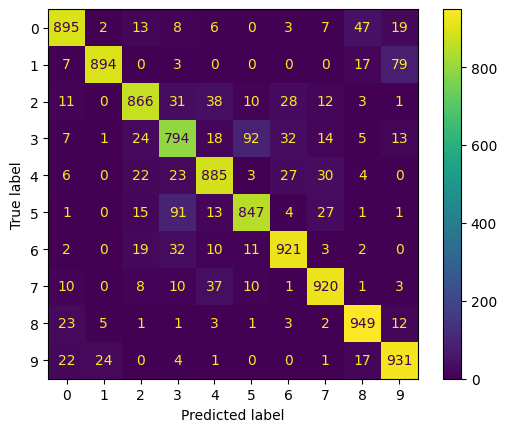

---------------------------------------------------------------------------



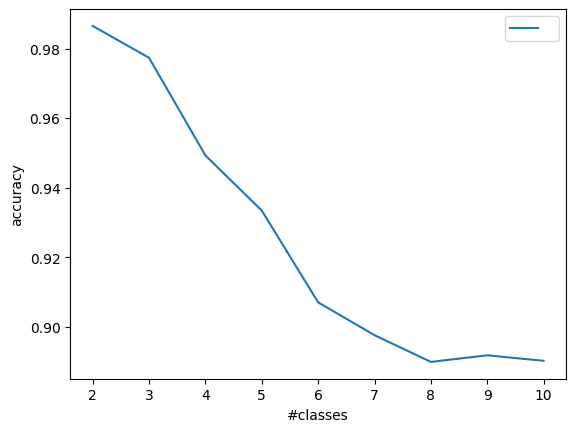

In [6]:
acc_list4 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=True, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

## Continually adding classes to the same model without the previous data

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 8.
Epoch 13: early stopping


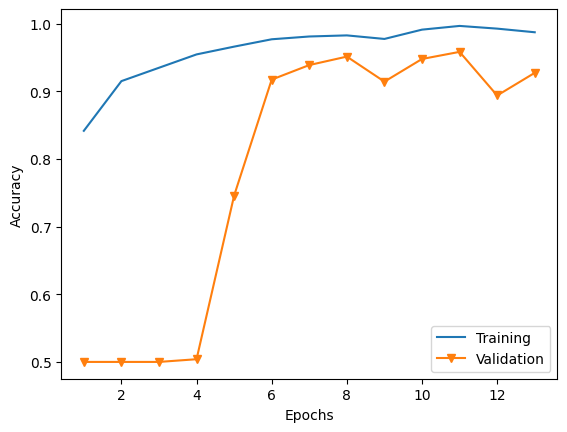

63/63 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9330    0.9610    0.9468      1000
           1     0.9598    0.9310    0.9452      1000

    accuracy                         0.9460      2000
   macro avg     0.9464    0.9460    0.9460      2000
weighted avg     0.9464    0.9460    0.9460      2000



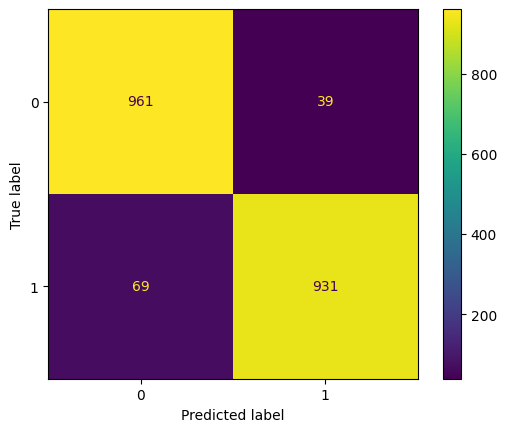

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


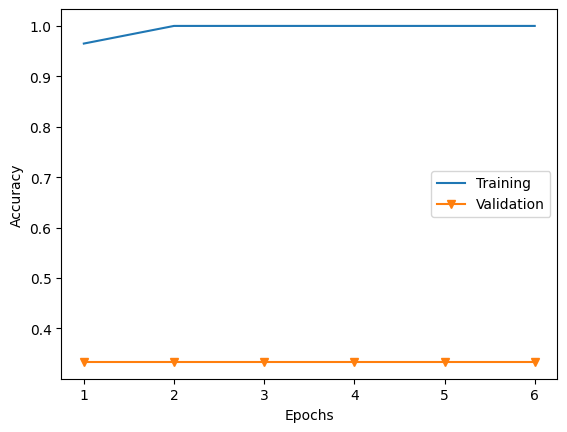

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.3333    1.0000    0.5000      1000

    accuracy                         0.3333      3000
   macro avg     0.1111    0.3333    0.1667      3000
weighted avg     0.1111    0.3333    0.1667      3000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


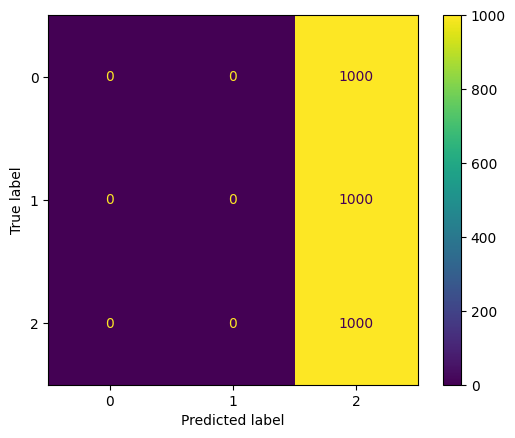

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


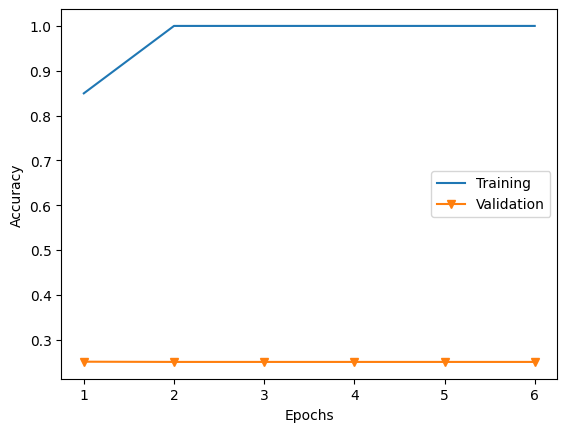

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.2857    0.0040    0.0079      1000
           3     0.2496    0.9950    0.3991      1000

    accuracy                         0.2497      4000
   macro avg     0.1338    0.2497    0.1018      4000
weighted avg     0.1338    0.2497    0.1018      4000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


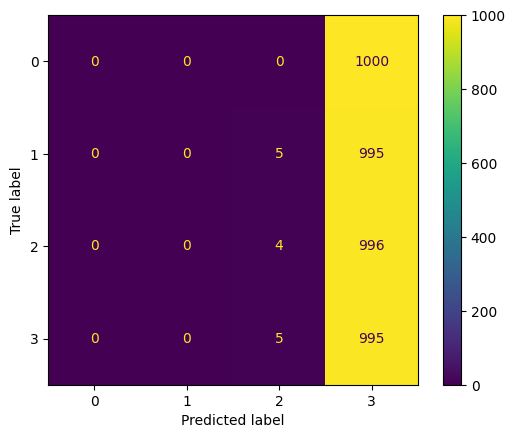

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


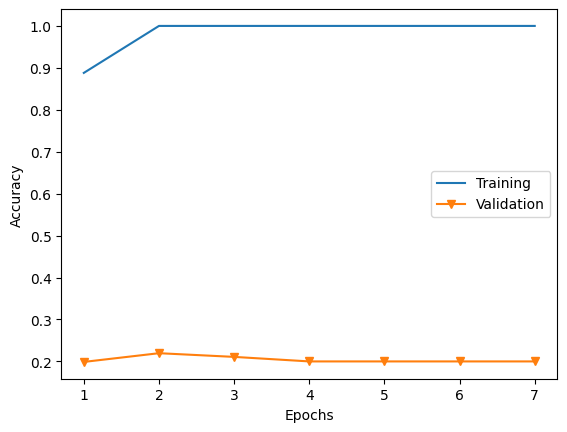

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.3422    0.2560    0.2929      1000
           4     0.2037    0.8660    0.3298      1000

    accuracy                         0.2244      5000
   macro avg     0.1092    0.2244    0.1245      5000
weighted avg     0.1092    0.2244    0.1245      5000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


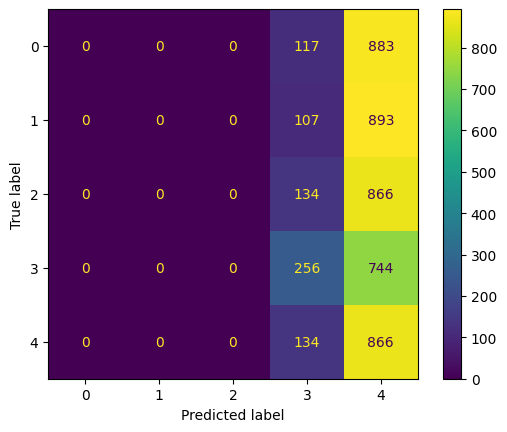

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


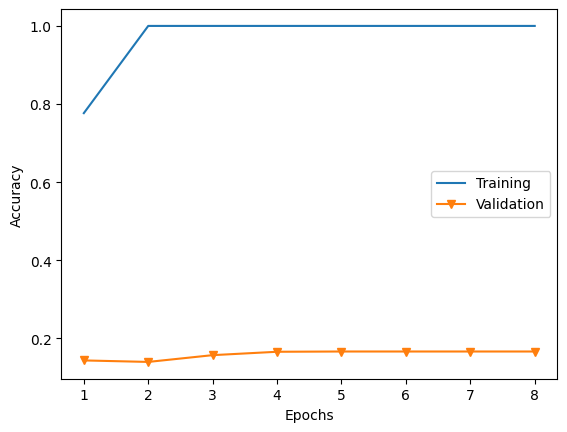

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0748    0.0160    0.0264      1000
           5     0.1613    0.9330    0.2750      1000

    accuracy                         0.1582      6000
   macro avg     0.0393    0.1582    0.0502      6000
weighted avg     0.0393    0.1582    0.0502      6000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


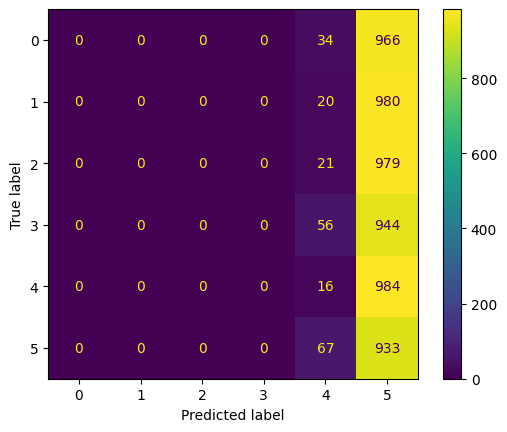

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


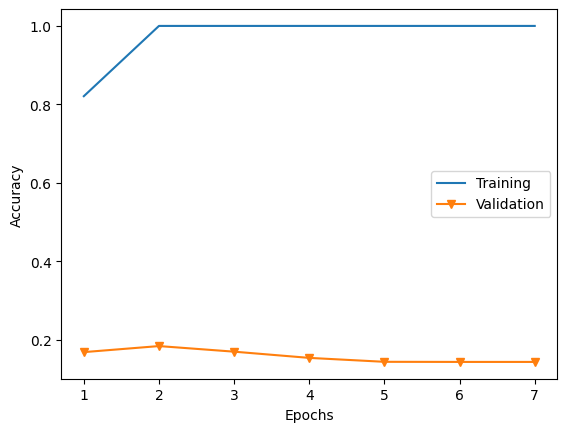

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.1639    0.6520    0.2620      1000
           6     0.2062    0.6230    0.3098      1000

    accuracy                         0.1821      7000
   macro avg     0.0529    0.1821    0.0817      7000
weighted avg     0.0529    0.1821    0.0817      7000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


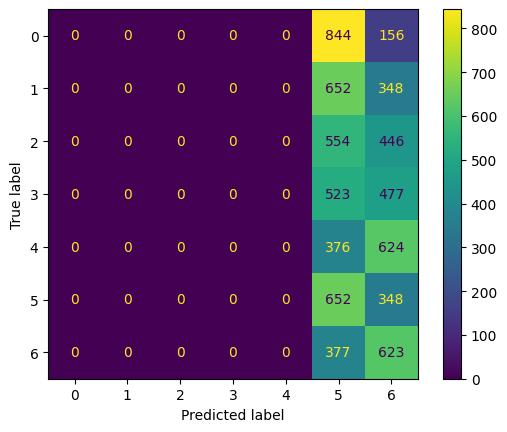

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


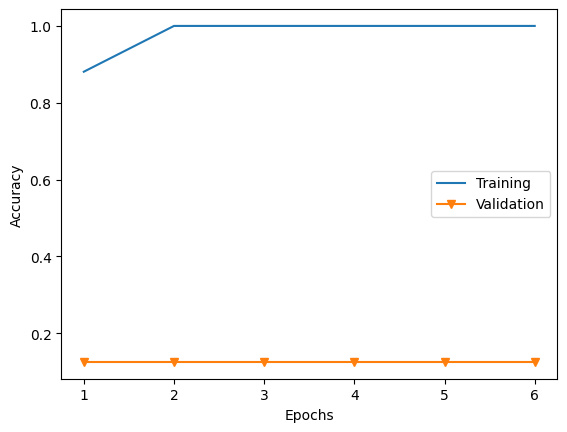

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.1250    1.0000    0.2222      1000

    accuracy                         0.1250      8000
   macro avg     0.0156    0.1250    0.0278      8000
weighted avg     0.0156    0.1250    0.0278      8000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


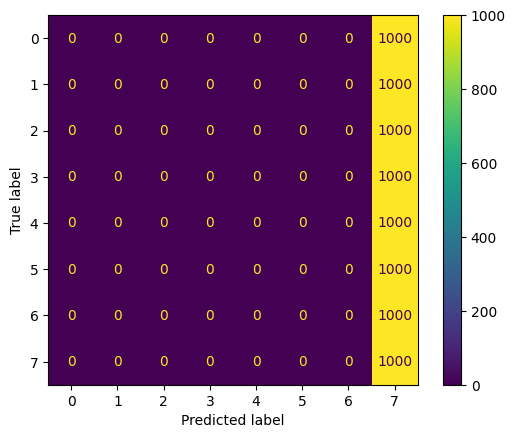

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


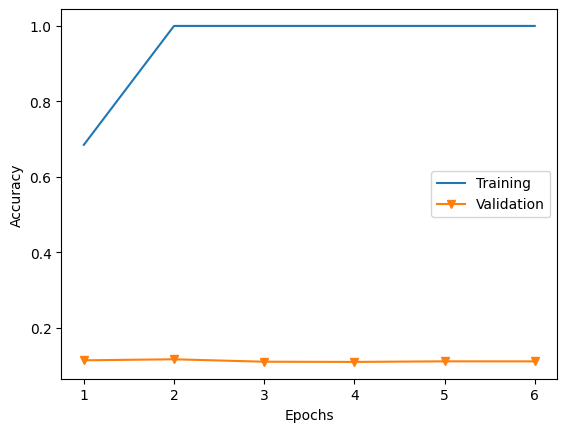

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.1083    0.4520    0.1747      1000
           8     0.1138    0.5490    0.1885      1000

    accuracy                         0.1112      9000
   macro avg     0.0247    0.1112    0.0404      9000
weighted avg     0.0247    0.1112    0.0404      9000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


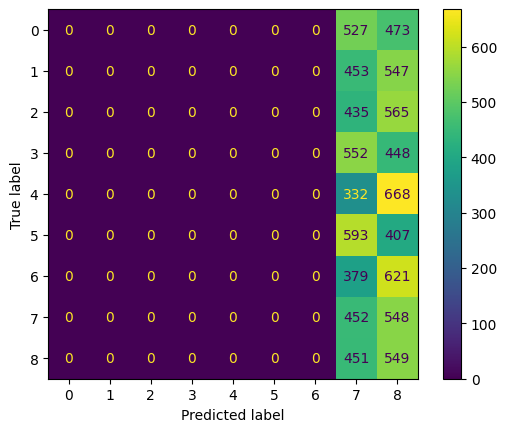

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


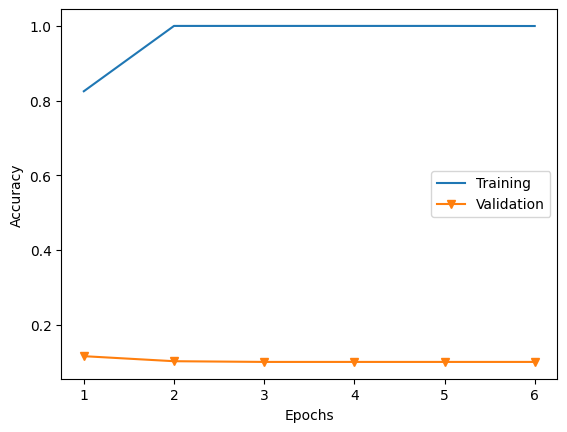

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.0000    0.0000    0.0000      1000
           8     0.1272    0.2390    0.1660      1000
           9     0.1154    0.9370    0.2055      1000

    accuracy                         0.1176     10000
   macro avg     0.0243    0.1176    0.0371     10000
weighted avg     0.0243    0.1176    0.0371     10000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


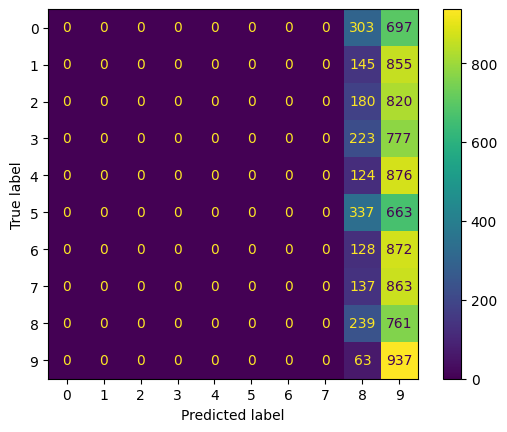

---------------------------------------------------------------------------



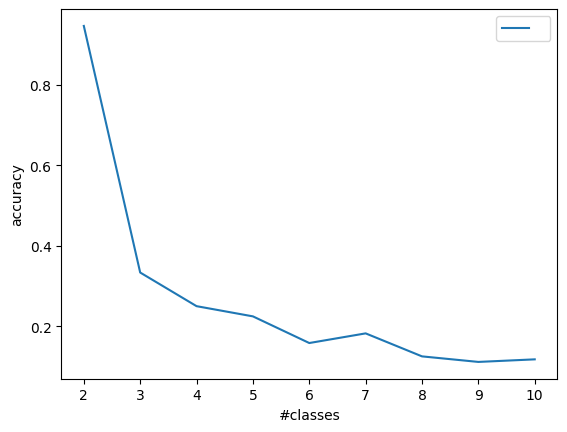

In [7]:
acc_list5 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=True, 
    remove_prev_classes=True, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


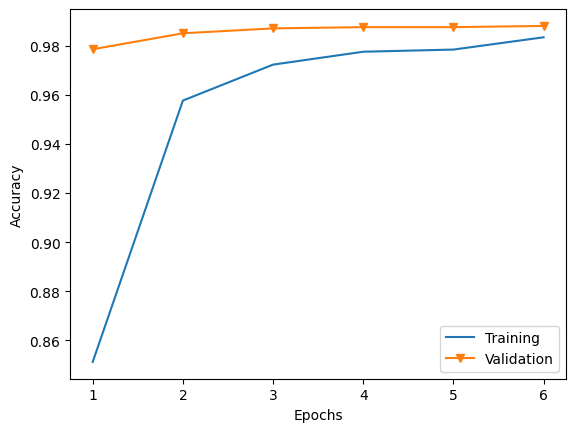

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9829    0.9760    0.9794      1000
           1     0.9762    0.9830    0.9796      1000

    accuracy                         0.9795      2000
   macro avg     0.9795    0.9795    0.9795      2000
weighted avg     0.9795    0.9795    0.9795      2000



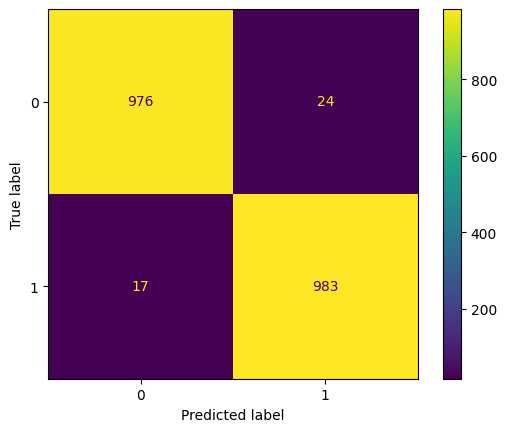

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


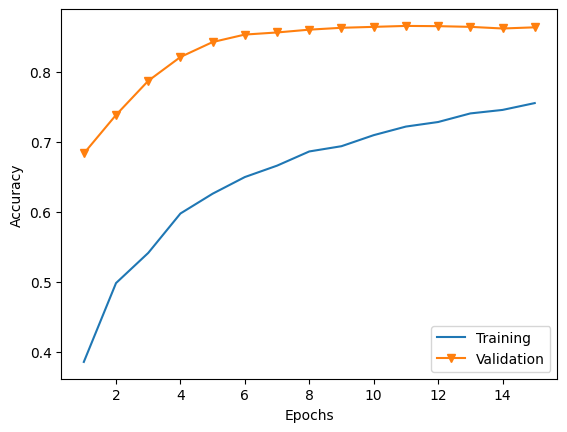

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8427    0.8570    0.8498      1000
           1     0.8468    0.9730    0.9055      1000
           2     0.9424    0.7860    0.8571      1000

    accuracy                         0.8720      3000
   macro avg     0.8773    0.8720    0.8708      3000
weighted avg     0.8773    0.8720    0.8708      3000



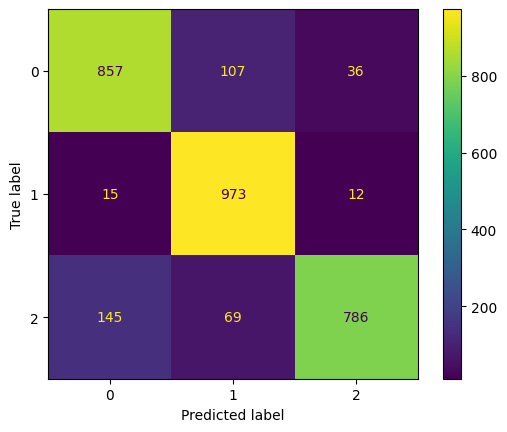

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


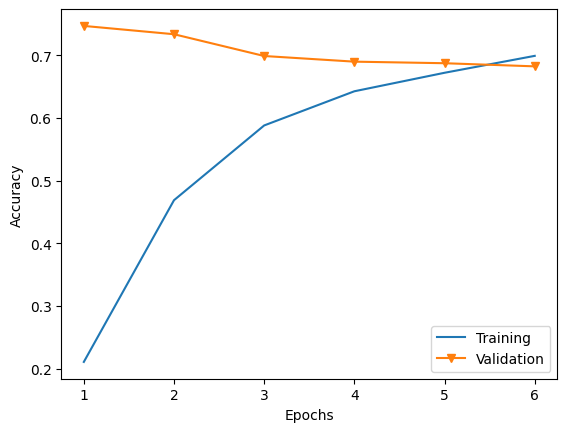

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8261    0.7270    0.7734      1000
           1     0.7303    0.9290    0.8178      1000
           2     0.7252    0.8050    0.7630      1000
           3     0.7832    0.5780    0.6651      1000

    accuracy                         0.7598      4000
   macro avg     0.7662    0.7598    0.7548      4000
weighted avg     0.7662    0.7598    0.7548      4000



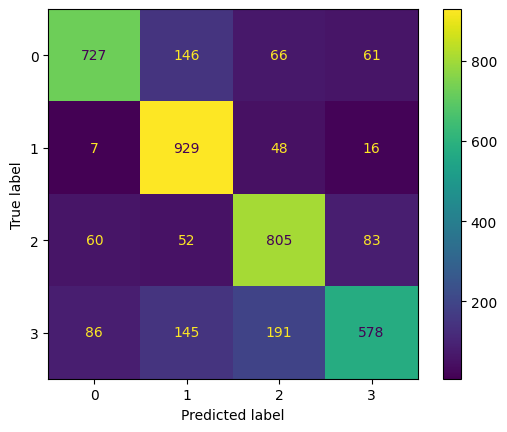

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


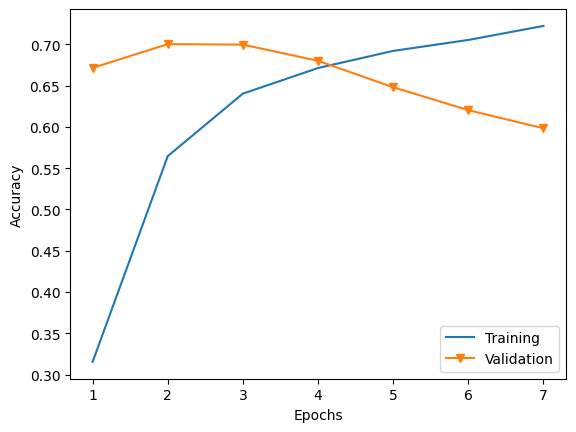

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.7444    0.6930    0.7178      1000
           1     0.8571    0.7740    0.8135      1000
           2     0.5888    0.4640    0.5190      1000
           3     0.6824    0.7520    0.7155      1000
           4     0.6536    0.8340    0.7329      1000

    accuracy                         0.7034      5000
   macro avg     0.7053    0.7034    0.6997      5000
weighted avg     0.7053    0.7034    0.6997      5000



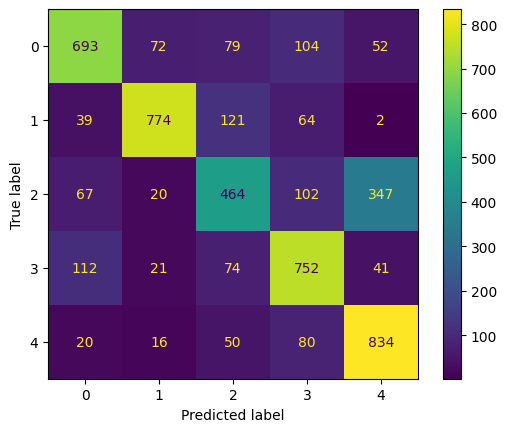

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


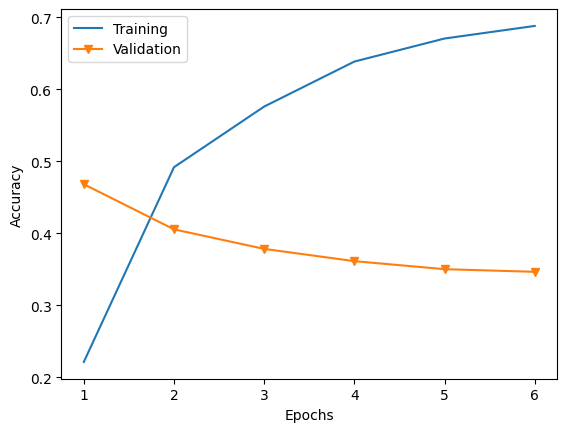

188/188 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8729    0.5150    0.6478      1000
           1     0.7723    0.3900    0.5183      1000
           2     0.2787    0.4400    0.3412      1000
           3     0.5056    0.4960    0.5008      1000
           4     0.5322    0.5790    0.5546      1000
           5     0.3540    0.4450    0.3943      1000

    accuracy                         0.4775      6000
   macro avg     0.5526    0.4775    0.4928      6000
weighted avg     0.5526    0.4775    0.4928      6000



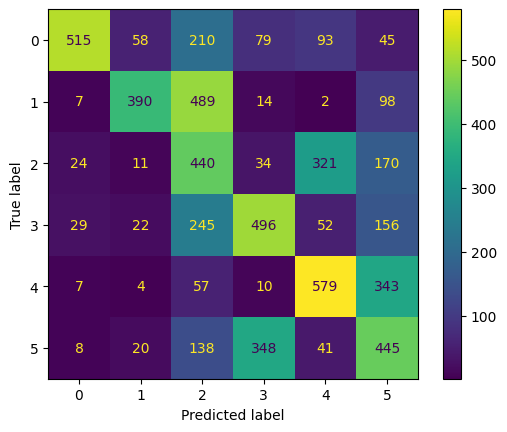

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


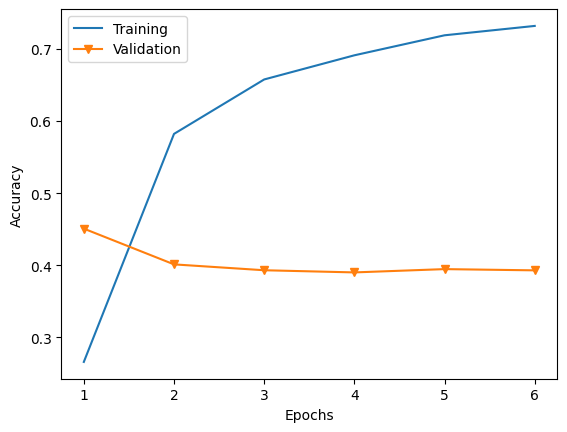

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.7717    0.5070    0.6119      1000
           1     0.8049    0.3260    0.4641      1000
           2     0.1793    0.3100    0.2272      1000
           3     0.5577    0.3190    0.4059      1000
           4     0.5171    0.4090    0.4567      1000
           5     0.5582    0.5320    0.5448      1000
           6     0.3909    0.7400    0.5116      1000

    accuracy                         0.4490      7000
   macro avg     0.5400    0.4490    0.4603      7000
weighted avg     0.5400    0.4490    0.4603      7000



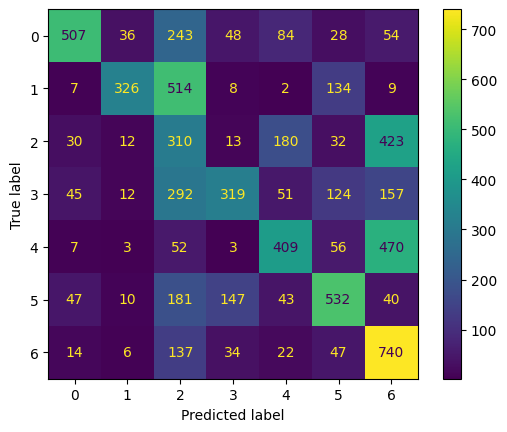

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


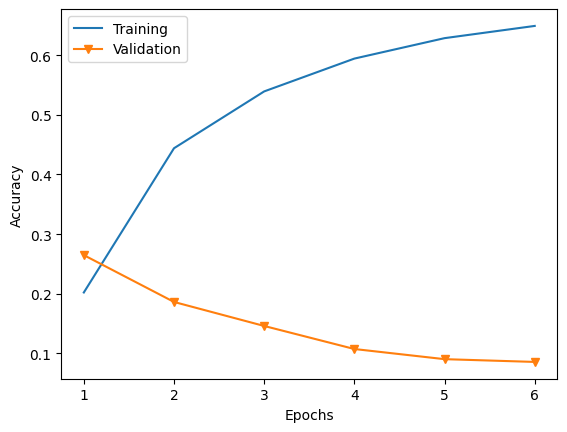

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.4000    0.0100    0.0195      1000
           1     0.9423    0.2940    0.4482      1000
           2     0.1687    0.0690    0.0979      1000
           3     0.5825    0.0600    0.1088      1000
           4     0.3230    0.3450    0.3337      1000
           5     0.4634    0.4050    0.4322      1000
           6     0.3707    0.7240    0.4903      1000
           7     0.0697    0.2270    0.1067      1000

    accuracy                         0.2667      8000
   macro avg     0.4150    0.2667    0.2547      8000
weighted avg     0.4150    0.2667    0.2547      8000



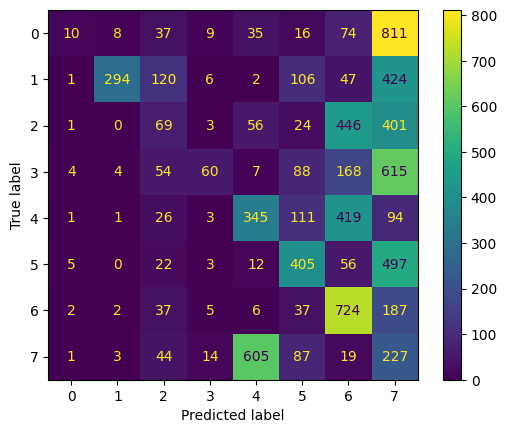

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


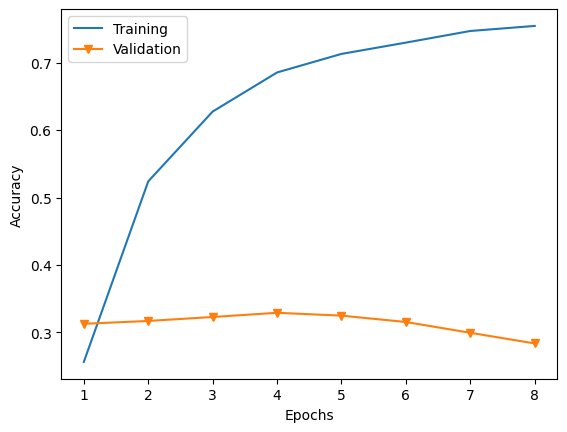

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.1852    0.1150    0.1419      1000
           1     0.7030    0.2580    0.3775      1000
           2     0.2241    0.1620    0.1880      1000
           3     0.6104    0.0470    0.0873      1000
           4     0.2771    0.2020    0.2337      1000
           5     0.4132    0.5140    0.4581      1000
           6     0.3384    0.7730    0.4708      1000
           7     0.0681    0.0680    0.0680      1000
           8     0.4254    0.8320    0.5629      1000

    accuracy                         0.3301      9000
   macro avg     0.3605    0.3301    0.2876      9000
weighted avg     0.3605    0.3301    0.2876      9000



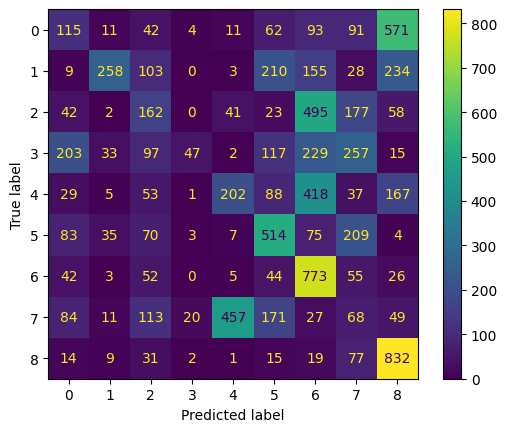

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


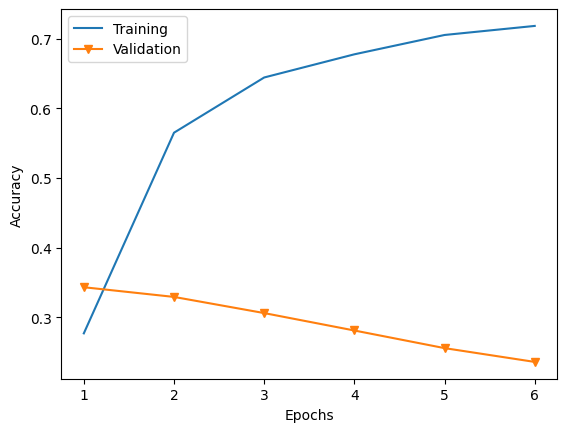

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.1574    0.1190    0.1355      1000
           1     0.1810    0.1280    0.1500      1000
           2     0.2976    0.1470    0.1968      1000
           3     0.7759    0.0900    0.1613      1000
           4     0.2431    0.2830    0.2616      1000
           5     0.6403    0.3720    0.4706      1000
           6     0.3653    0.7270    0.4863      1000
           7     0.0665    0.0340    0.0450      1000
           8     0.4403    0.8040    0.5690      1000
           9     0.4232    0.7850    0.5499      1000

    accuracy                         0.3489     10000
   macro avg     0.3591    0.3489    0.3026     10000
weighted avg     0.3591    0.3489    0.3026     10000



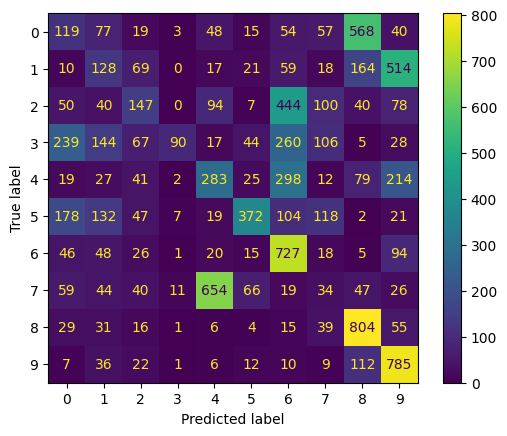

---------------------------------------------------------------------------



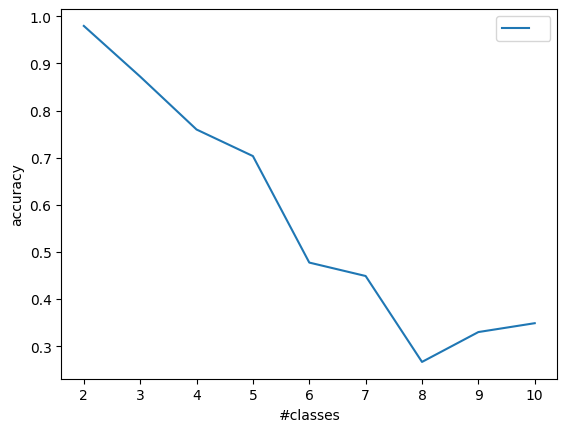

In [8]:
from tensorflow.keras import optimizers

from filtered_loss import FilteredLoss
from utils import get_compile_args


acc_list6 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=True, 
    remove_prev_classes=True, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    onehot_labels=True,
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS, 
    compile_args=get_compile_args(
        optimizer=optimizers.Adam(learning_rate=5e-5), 
        loss=FilteredLoss()
    )
)

## Conclusion

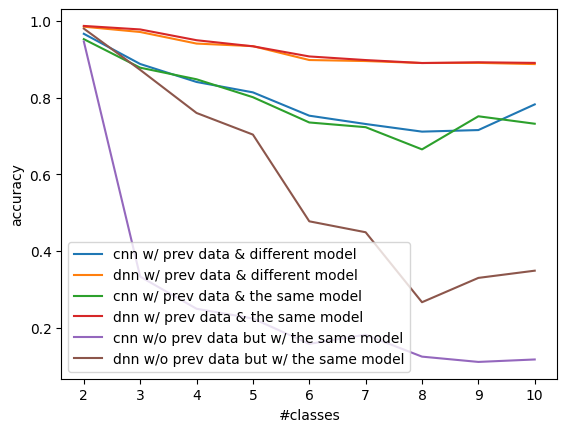

In [9]:
CL_plot(CLASS_NUM, 
    [
    (acc_list1, "cnn w/ prev data & different model"), 
    (acc_list2, "dnn w/ prev data & different model"), 
    (acc_list3, "cnn w/ prev data & the same model"), 
    (acc_list4, "dnn w/ prev data & the same model"), 
    (acc_list5, "cnn w/o prev data but w/ the same model"), 
    (acc_list6, "dnn w/o prev data but w/ the same model"), 
    ]
)